# 🩺 DIABETES PREDICTION - COMPREHENSIVE ML & VISUALIZATION

## Dataset: Diabetes Prediction Dataset
**Kaynak:** https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

## 🎯 Proje Hedefi: DIYABET TAHMINI (BINARY CLASSIFICATION)

## 📊 Proje Ozellikleri:
- **Detayli EDA** - Diabetes-specific insights
- **20+ Gorsellestirme** - Her acidan analiz
- **Dataset'e Uygun ML Modeller** - 10+ classification models
- **Comprehensive Model Comparison** - Hem gorsel hem tablo
- **Cost-Sensitive Learning** - False Negative odakli
- **Class Imbalance Handling** - SMOTE + class weights
- **Medical Metrics** - Sensitivity, Specificity

## 📋 Proje Adimlari:
1. Veri Yukleme & Ilk Bakis
2. **DETAYLI EDA** (20+ grafik)
3. Veri Temizleme & Feature Engineering
4. **10+ ML Model Egitimi**
5. **KAPSAMLI MODEL KARSILASTIRMASI** (Gorsel + Tablo)
6. Medical Insights & Recommendations

## 1️⃣ KUTUPHANE YUKLEME

In [2]:
# Temel kutuphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Sistem
import os
import subprocess
import zipfile
import glob

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

# ML Modelleri
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# CatBoost'u yükle (Eğer yüklü değilse)
try:
    from catboost import CatBoostClassifier
except ImportError:
    print("CatBoost kütüphanesi bulunamadı. Yükleniyor...")
    !pip install catboost -qq
    from catboost import CatBoostClassifier

# Metrikler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score,
    matthews_corrcoef, cohen_kappa_score
)

# Plotly
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY = True
except:
    PLOTLY = False

# Gorsellestirme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

# Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('='*80)
print('KUTUPHANELER YUKLENDI!')
print('='*80)
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'Plotly: {"Available" if PLOTLY else "Not Available"}')
print('='*80)


CatBoost kütüphanesi bulunamadı. Yükleniyor...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.0 MB/s eta 0:00:00
KUTUPHANELER YUKLENDI!
NumPy: 2.0.2
Pandas: 2.2.2
Plotly: Available


## 2️⃣ VERI YUKLEME

In [3]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)
    print(f"INDIRILIYOR: {zip_filename}")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        return True
    except:
        return False

def extract_dataset(dest_folder):
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        for zip_file in zip_files:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
        return True
    except:
        return False

In [4]:
# Dataset indirme
dataset_folder = "diabetes_dataset"
os.makedirs(dataset_folder, exist_ok=True)

dataset_info = {
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/iammustafatz/diabetes-prediction-dataset",
    "folder": dataset_folder,
    "zip_filename": "diabetes.zip"
}

csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if not csv_files:
    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )
    if success:
        extract_dataset(dataset_info["folder"])
else:
    print("Dataset zaten mevcut!")

INDIRILIYOR: diabetes.zip


In [5]:
# Veri yukleme
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if csv_files:
    df = pd.read_csv(csv_files[0])

    print('='*80)
    print('VERI YUKLENDI!')
    print('='*80)
    print(f'Toplam Kayit: {len(df):,}')
    print(f'Sutun Sayisi: {len(df.columns)}')
    print(f'Bellek: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
    print('='*80)
else:
    print('CSV dosyasi bulunamadi!')

VERI YUKLENDI!
Toplam Kayit: 100,000
Sutun Sayisi: 9
Bellek: 15.78 MB


In [6]:
# Ilk bakis
print('ILK 10 KAYIT:')
df.head(10)

ILK 10 KAYIT:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0000,0,1,never,25.1900,6.6000,140,0
1,Female,54.0000,0,0,No Info,27.3200,6.6000,80,0
2,Male,28.0000,0,0,never,27.3200,5.7000,158,0
3,Female,36.0000,0,0,current,23.4500,5.0000,155,0
4,Male,76.0000,1,1,current,20.1400,4.8000,155,0
5,Female,20.0000,0,0,never,27.3200,6.6000,85,0
6,Female,44.0000,0,0,never,19.3100,6.5000,200,1
7,Female,79.0000,0,0,No Info,23.8600,5.7000,85,0
8,Male,42.0000,0,0,never,33.6400,4.8000,145,0
9,Female,32.0000,0,0,never,27.3200,5.0000,100,0


In [7]:
# Veri yapisi
print('VERI YAPISI:')
print('='*80)
df.info()

VERI YAPISI:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [8]:
# Istatistiksel ozet
print('ISTATISTIKSEL OZET:')
print('='*80)
df.describe(include='all').T

ISTATISTIKSEL OZET:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0000,NaN,NaN,NaN,41.8859,22.5168,0.0800,24.0000,43.0000,60.0000,80.0000
hypertension,100000.0000,NaN,NaN,NaN,0.0748,0.2632,0.0000,0.0000,0.0000,0.0000,1.0000
heart_disease,100000.0000,NaN,NaN,NaN,0.0394,0.1946,0.0000,0.0000,0.0000,0.0000,1.0000
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0000,NaN,NaN,NaN,27.3208,6.6368,10.0100,23.6300,27.3200,29.5800,95.6900
HbA1c_level,100000.0000,NaN,NaN,NaN,5.5275,1.0707,3.5000,4.8000,5.8000,6.2000,9.0000
blood_glucose_level,100000.0000,NaN,NaN,NaN,138.0581,40.7081,80.0000,100.0000,140.0000,159.0000,300.0000
diabetes,100000.0000,NaN,NaN,NaN,0.0850,0.2789,0.0000,0.0000,0.0000,0.0000,1.0000


## 3️⃣ DETAYLI EDA - 20+ GORSELLESTIRME

### 🎯 Hedef Degisken Analizi

In [9]:
# Hedef degisken
target_col = 'diabetes' if 'diabetes' in df.columns else df.columns[-1]

print('='*80)
print(f'HEDEF DEGISKEN: {target_col}')
print('='*80)
print('Dagilim:')
print(df[target_col].value_counts())
print('Yuzde:')
print(df[target_col].value_counts(normalize=True) * 100)

# Class imbalance kontrolu
imbalance_ratio = df[target_col].value_counts().max() / df[target_col].value_counts().min()
print(f'Imbalance Ratio: {imbalance_ratio:.2f}')
if imbalance_ratio > 1.5:
    print('CLASS IMBALANCE TESPIT EDILDI!')

HEDEF DEGISKEN: diabetes
Dagilim:
diabetes
0    91500
1     8500
Name: count, dtype: int64
Yuzde:
diabetes
0   91.5000
1    8.5000
Name: proportion, dtype: float64
Imbalance Ratio: 10.76
CLASS IMBALANCE TESPIT EDILDI!


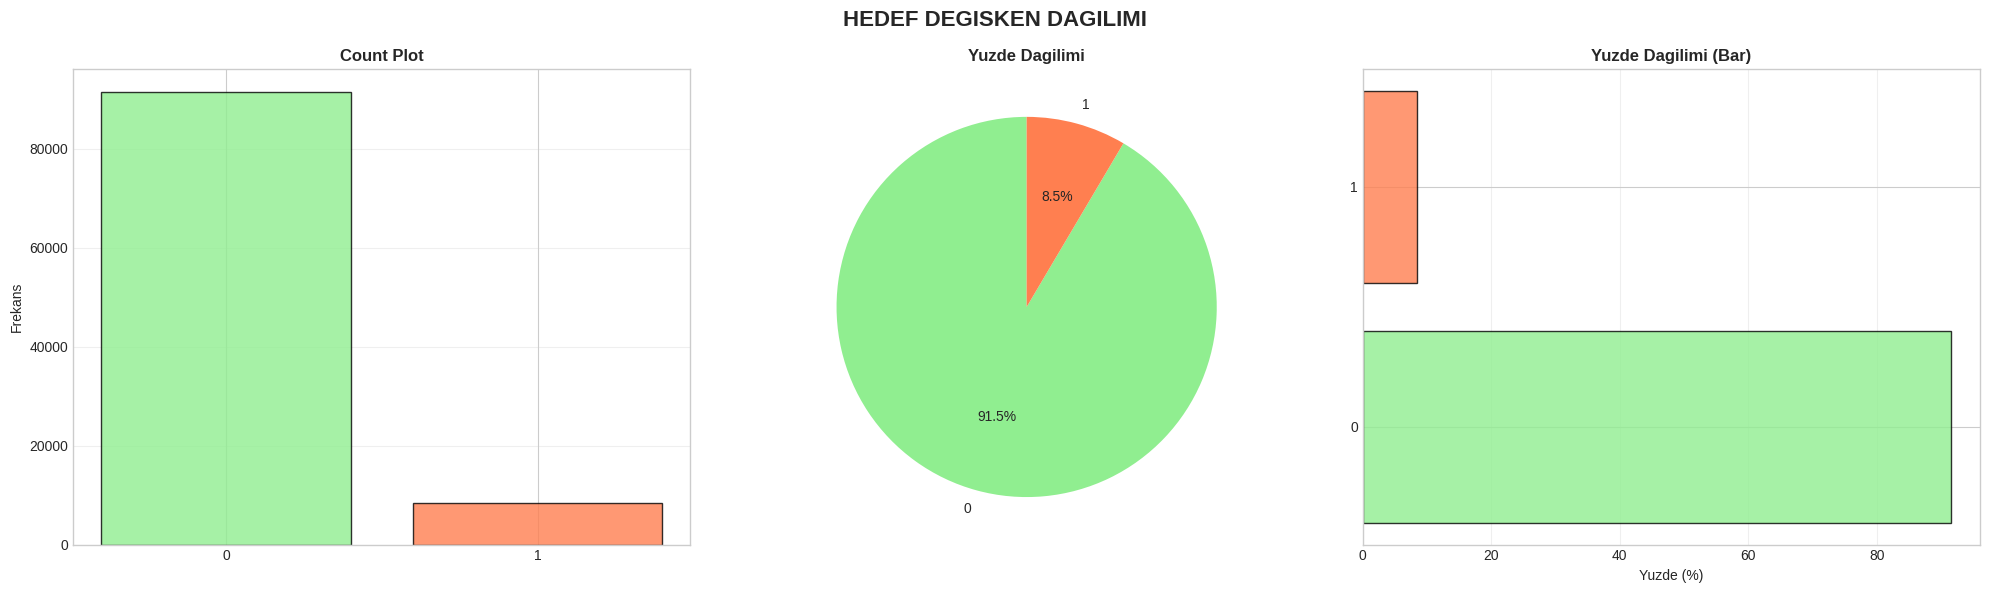

In [10]:
# Hedef degisken gorsellestirmesi
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('HEDEF DEGISKEN DAGILIMI', fontsize=16, fontweight='bold')

# Count plot
target_counts = df[target_col].value_counts()
axes[0].bar(range(len(target_counts)), target_counts.values,
           color=['lightgreen', 'coral'], edgecolor='black', alpha=0.8)
axes[0].set_xticks(range(len(target_counts)))
axes[0].set_xticklabels(target_counts.index)
axes[0].set_title('Count Plot', fontweight='bold')
axes[0].set_ylabel('Frekans')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
colors = ['lightgreen', 'coral']
axes[1].pie(target_counts.values, labels=target_counts.index,
           autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Yuzde Dagilimi', fontweight='bold')

# Percentage bar
target_pct = df[target_col].value_counts(normalize=True) * 100
axes[2].barh(range(len(target_pct)), target_pct.values,
            color=['lightgreen', 'coral'], edgecolor='black', alpha=0.8)
axes[2].set_yticks(range(len(target_pct)))
axes[2].set_yticklabels(target_pct.index)
axes[2].set_title('Yuzde Dagilimi (Bar)', fontweight='bold')
axes[2].set_xlabel('Yuzde (%)')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Eksik Veri Analizi

In [11]:
# Eksik veri analizi
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Eksik_Sayi': missing,
    'Eksik_Yuzde': missing_pct
}).sort_values('Eksik_Sayi', ascending=False)

print('='*80)
print('EKSIK VERI ANALIZI')
print('='*80)
print(missing_df[missing_df['Eksik_Sayi'] > 0])

if missing.sum() == 0:
    print('EKSIK VERI YOK!')
else:
    # Gorsellestirme
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    missing_top = missing_df[missing_df['Eksik_Sayi'] > 0]
    if len(missing_top) > 0:
        axes[0].barh(range(len(missing_top)), missing_top['Eksik_Yuzde'],
                    color='crimson', edgecolor='black', alpha=0.7)
        axes[0].set_yticks(range(len(missing_top)))
        axes[0].set_yticklabels(missing_top.index)
        axes[0].set_xlabel('Eksik Veri %')
        axes[0].set_title('Eksik Veri Dagilimi', fontweight='bold')
        axes[0].invert_yaxis()

    total_cells = len(df) * len(df.columns)
    missing_cells = missing.sum()
    present_cells = total_cells - missing_cells

    axes[1].pie([present_cells, missing_cells],
               labels=['Mevcut', 'Eksik'],
               autopct='%1.2f%%',
               colors=['lightgreen', 'lightcoral'])
    axes[1].set_title('Genel Veri Durumu', fontweight='bold')

    plt.tight_layout()
    plt.show()

EKSIK VERI ANALIZI
Empty DataFrame
Columns: [Eksik_Sayi, Eksik_Yuzde]
Index: []
EKSIK VERI YOK!


### 📈 Sayisal Degisken Analizleri

In [12]:
# Sayisal sutunlar
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

print(f'SAYISAL DEGISKENLER ({len(numeric_cols)} adet):')
print(numeric_cols)

# Her numeric degisken icin ozet
for col in numeric_cols:
    print(f'{col}:')
    print(f'  Ortalama: {df[col].mean():.2f}')
    print(f'  Medyan: {df[col].median():.2f}')
    print(f'  Std: {df[col].std():.2f}')
    print(f'  Min: {df[col].min():.2f}')
    print(f'  Max: {df[col].max():.2f}')

SAYISAL DEGISKENLER (6 adet):
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
age:
  Ortalama: 41.89
  Medyan: 43.00
  Std: 22.52
  Min: 0.08
  Max: 80.00
hypertension:
  Ortalama: 0.07
  Medyan: 0.00
  Std: 0.26
  Min: 0.00
  Max: 1.00
heart_disease:
  Ortalama: 0.04
  Medyan: 0.00
  Std: 0.19
  Min: 0.00
  Max: 1.00
bmi:
  Ortalama: 27.32
  Medyan: 27.32
  Std: 6.64
  Min: 10.01
  Max: 95.69
HbA1c_level:
  Ortalama: 5.53
  Medyan: 5.80
  Std: 1.07
  Min: 3.50
  Max: 9.00
blood_glucose_level:
  Ortalama: 138.06
  Medyan: 140.00
  Std: 40.71
  Min: 80.00
  Max: 300.00


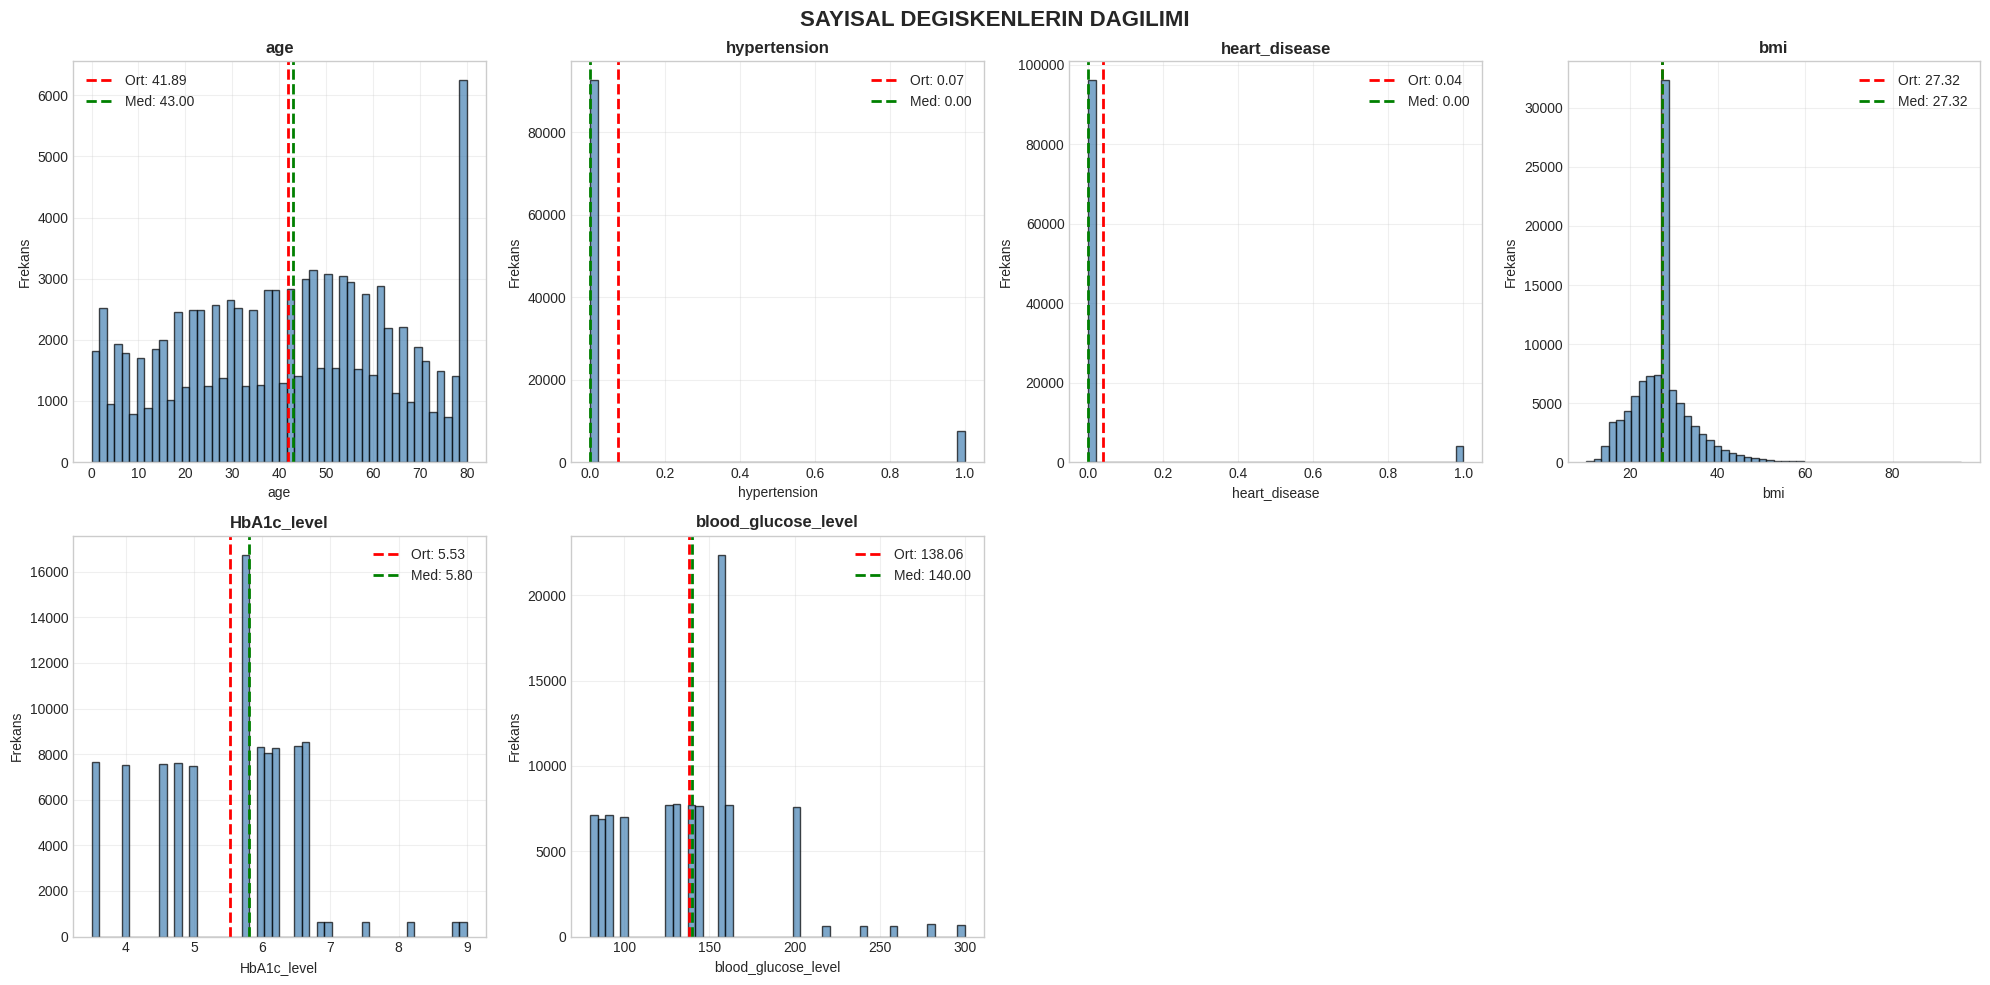

In [13]:
# Distribution plots
n_cols = min(4, len(numeric_cols))
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('SAYISAL DEGISKENLERIN DAGILIMI', fontsize=16, fontweight='bold')
axes = axes.flatten() if len(numeric_cols) > 1 else [axes]

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col].dropna(), bins=50, color='steelblue',
                  edgecolor='black', alpha=0.7)
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--',
                     linewidth=2, label=f'Ort: {df[col].mean():.2f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--',
                     linewidth=2, label=f'Med: {df[col].median():.2f}')
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frekans')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

# Bos subplotlari gizle
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

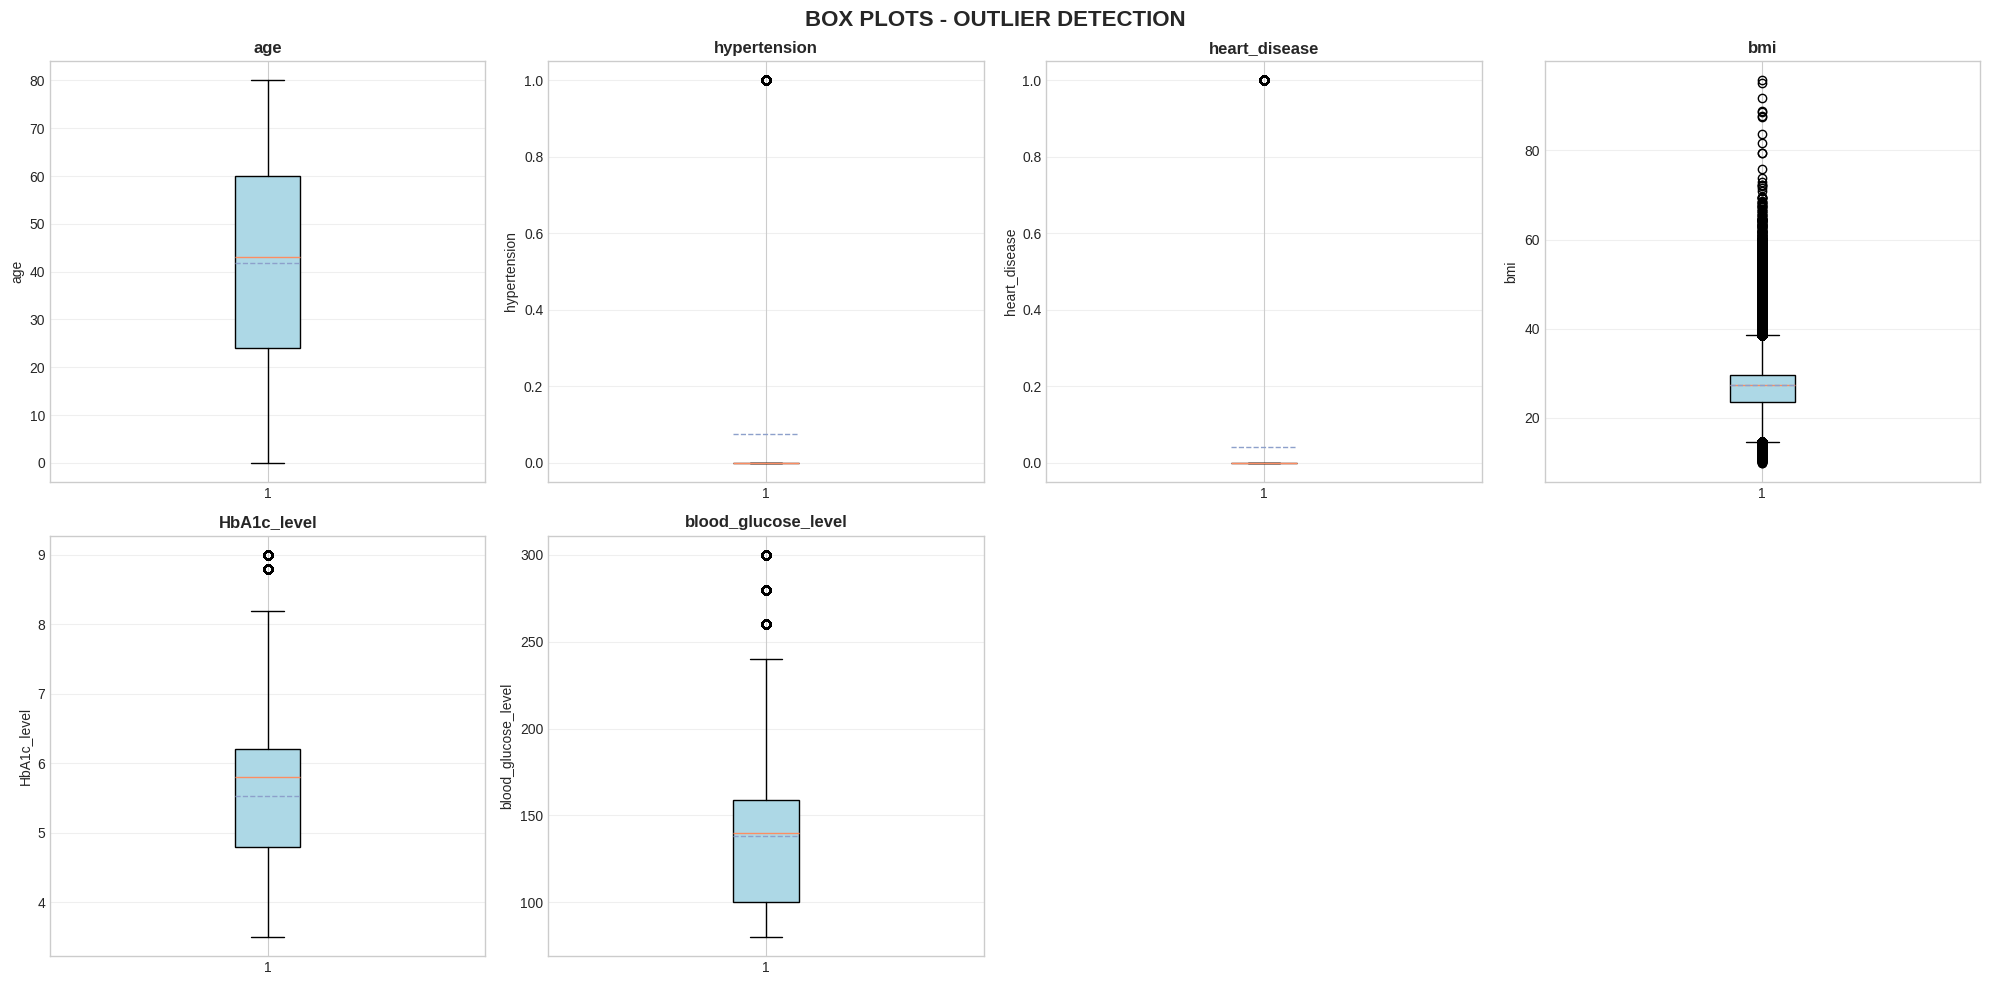

In [14]:
# Box plots - Outlier detection
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('BOX PLOTS - OUTLIER DETECTION', fontsize=16, fontweight='bold')
axes = axes.flatten() if len(numeric_cols) > 1 else [axes]

for idx, col in enumerate(numeric_cols):
    bp = axes[idx].boxplot([df[col].dropna()], patch_artist=True,
                           showmeans=True, meanline=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(axis='y', alpha=0.3)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

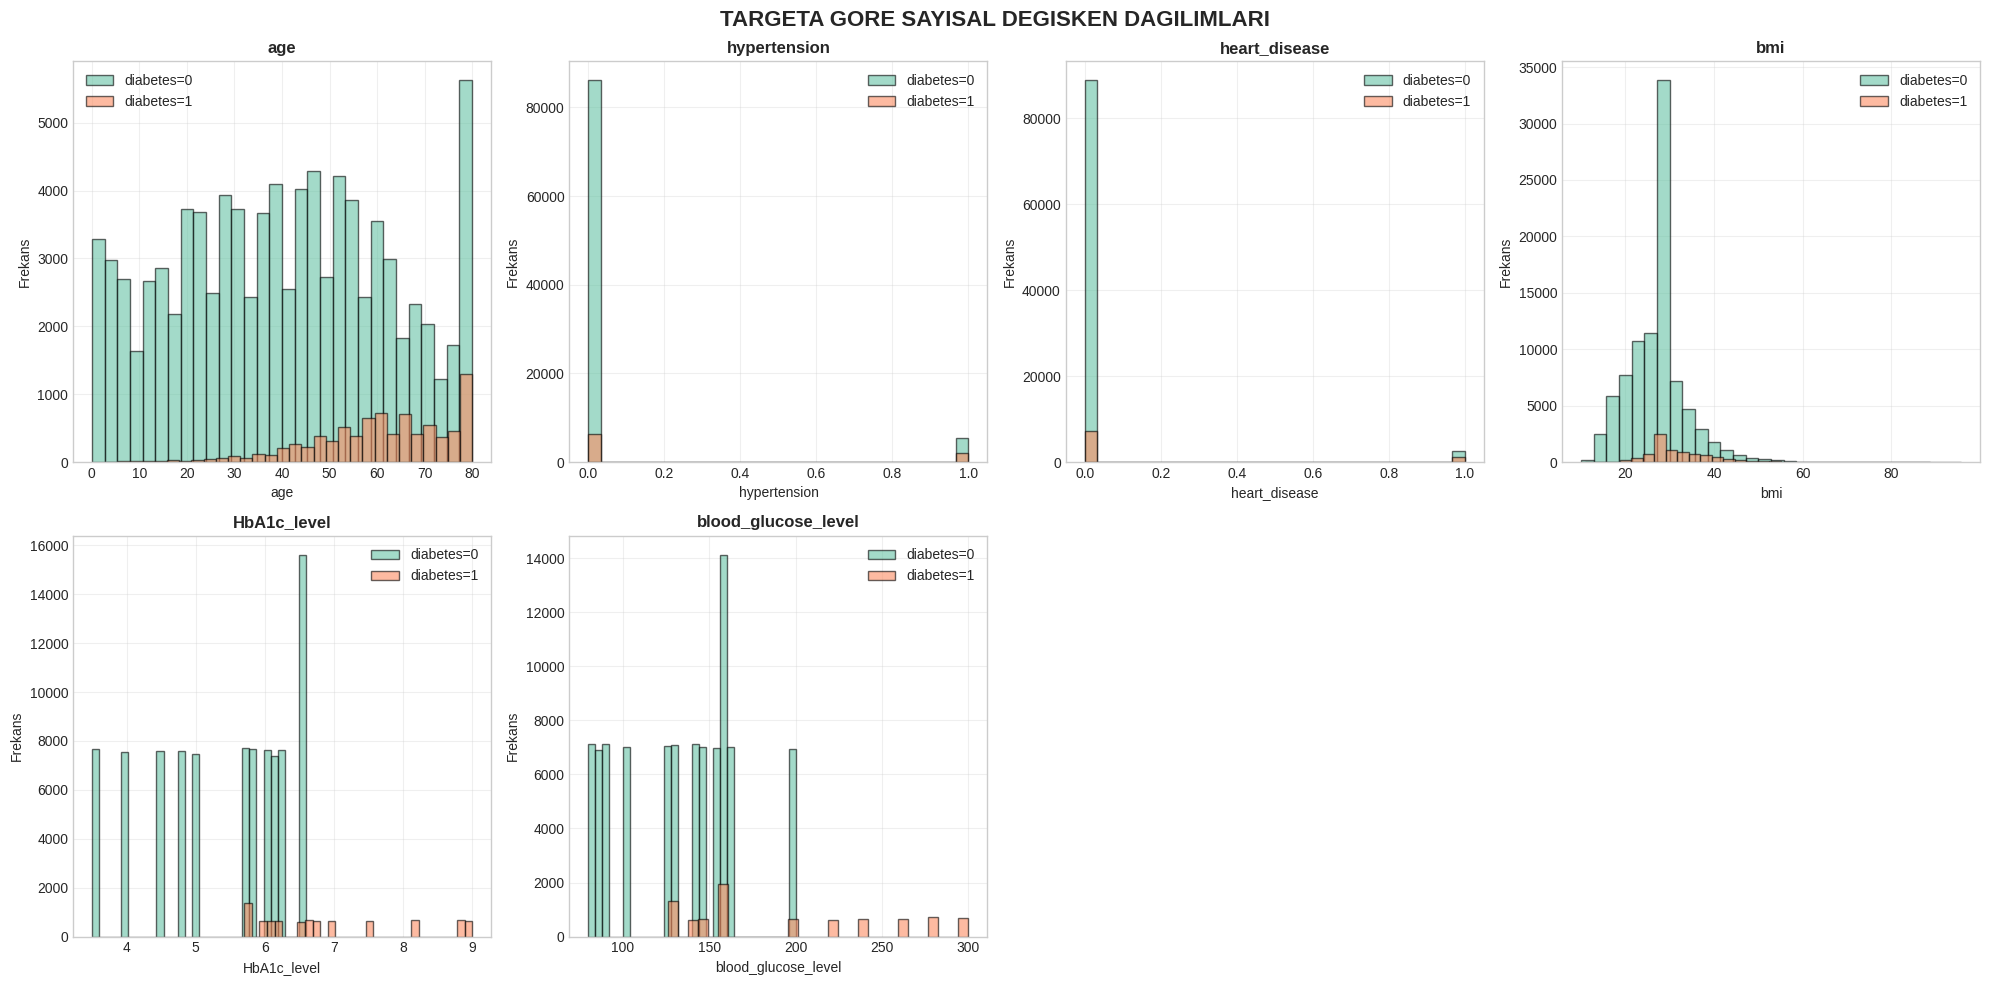

In [15]:
# Target'a gore dagilimlar
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('TARGETA GORE SAYISAL DEGISKEN DAGILIMLARI', fontsize=16, fontweight='bold')
axes = axes.flatten() if len(numeric_cols) > 1 else [axes]

for idx, col in enumerate(numeric_cols):
    for target_val in sorted(df[target_col].unique()):
        subset = df[df[target_col] == target_val][col].dropna()
        axes[idx].hist(subset, bins=30, alpha=0.6,
                      label=f'{target_col}={target_val}',
                      edgecolor='black')
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frekans')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### 🏷️ Kategorik Degisken Analizleri

In [16]:
# Kategorik sutunlar
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

print(f'KATEGORIK DEGISKENLER ({len(categorical_cols)} adet):')
for col in categorical_cols:
    print(f'{col}:')
    print(f'  Benzersiz: {df[col].nunique()}')
    print(f'  Top 5:')
    print(df[col].value_counts().head(5))

KATEGORIK DEGISKENLER (2 adet):
gender:
  Benzersiz: 3
  Top 5:
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64
smoking_history:
  Benzersiz: 6
  Top 5:
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
Name: count, dtype: int64


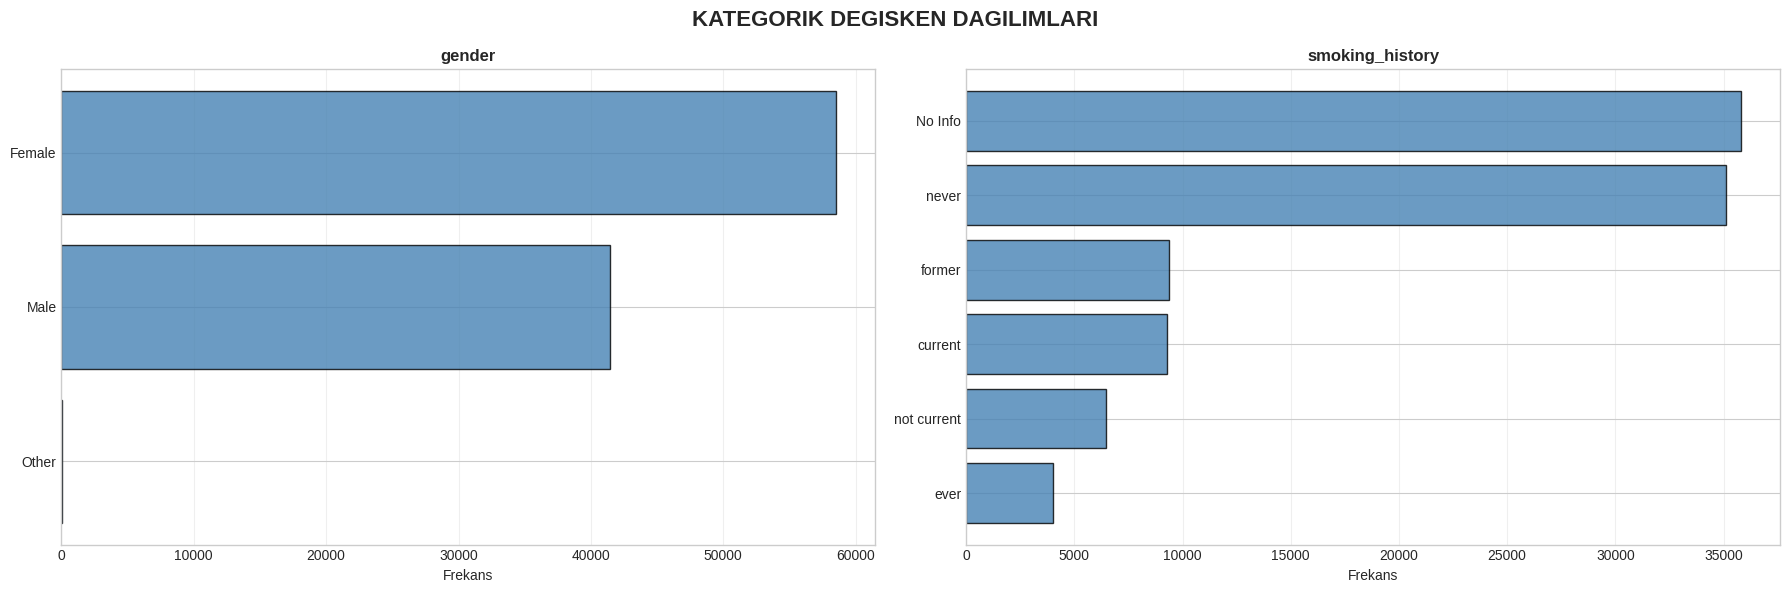

In [17]:
# Kategorik degisken gorsellestirmesi
if len(categorical_cols) > 0:
    n_cols_cat = min(2, len(categorical_cols))
    n_rows_cat = (len(categorical_cols) + n_cols_cat - 1) // n_cols_cat

    fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(18, 6*n_rows_cat))
    fig.suptitle('KATEGORIK DEGISKEN DAGILIMLARI', fontsize=16, fontweight='bold')
    axes = axes.flatten() if len(categorical_cols) > 1 else [axes]

    for idx, col in enumerate(categorical_cols):
        top_10 = df[col].value_counts().head(10)
        axes[idx].barh(range(len(top_10)), top_10.values,
                      color='steelblue', edgecolor='black', alpha=0.8)
        axes[idx].set_yticks(range(len(top_10)))
        axes[idx].set_yticklabels(top_10.index)
        axes[idx].set_title(f'{col}', fontweight='bold')
        axes[idx].set_xlabel('Frekans')
        axes[idx].invert_yaxis()
        axes[idx].grid(axis='x', alpha=0.3)

    for idx in range(len(categorical_cols), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

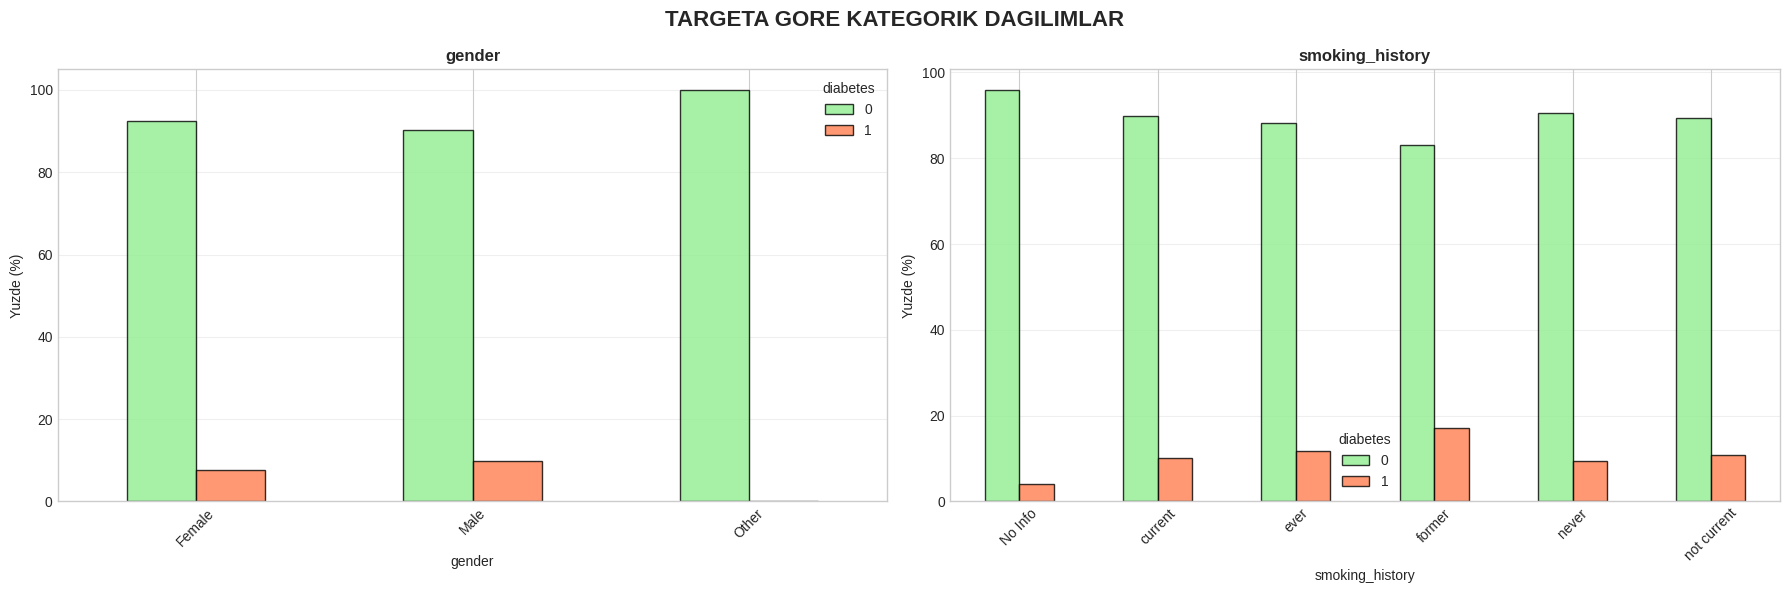

In [18]:
# Target'a gore kategorik analiz
if len(categorical_cols) > 0:
    fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(18, 6*n_rows_cat))
    fig.suptitle('TARGETA GORE KATEGORIK DAGILIMLAR', fontsize=16, fontweight='bold')
    axes = axes.flatten() if len(categorical_cols) > 1 else [axes]

    for idx, col in enumerate(categorical_cols):
        ct = pd.crosstab(df[col], df[target_col], normalize='index') * 100
        ct.plot(kind='bar', ax=axes[idx], stacked=False,
               color=['lightgreen', 'coral'], alpha=0.8,
               edgecolor='black')
        axes[idx].set_title(f'{col}', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Yuzde (%)')
        axes[idx].legend(title=target_col)
        axes[idx].grid(axis='y', alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=45)

    for idx in range(len(categorical_cols), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

### 🔗 Korelasyon Analizi

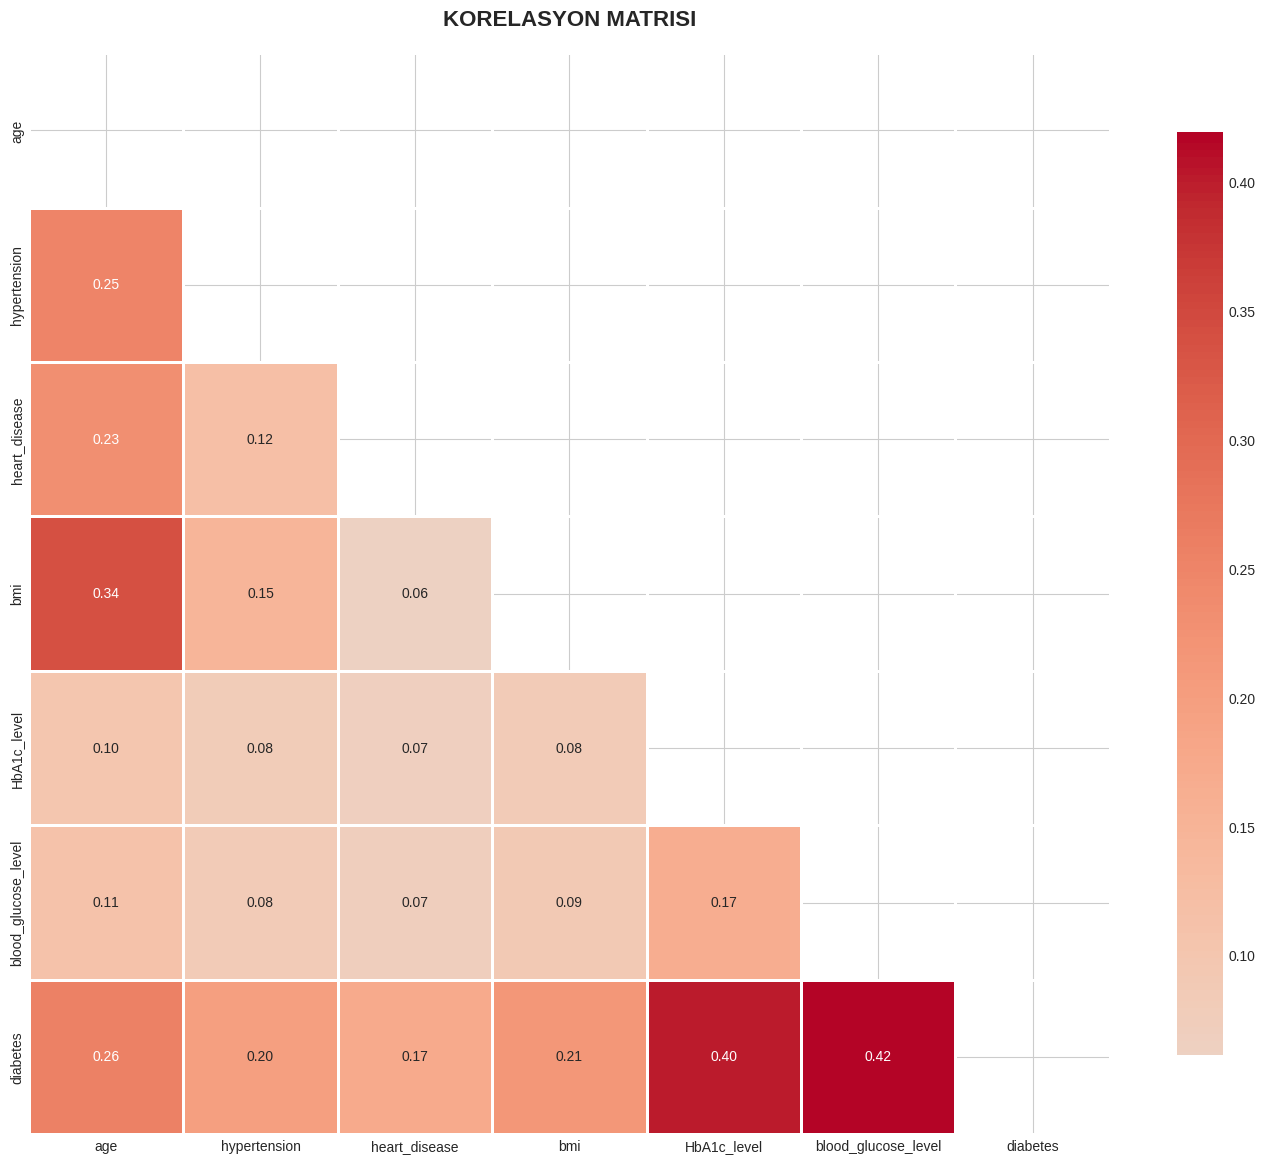

DIABETES ILE KORELASYONLAR:
diabetes              1.0000
blood_glucose_level   0.4196
HbA1c_level           0.4007
age                   0.2580
bmi                   0.2144
hypertension          0.1978
heart_disease         0.1717
Name: diabetes, dtype: float64


In [19]:
# Korelasyon matrisi
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
           cmap='coolwarm', center=0, linewidths=1,
           cbar_kws={'shrink': 0.8}, square=True)
plt.title('KORELASYON MATRISI', fontweight='bold', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Target ile en yuksek korelasyonlar
if target_col in corr.columns:
    target_corr = corr[target_col].abs().sort_values(ascending=False)
    print(f'{target_col.upper()} ILE KORELASYONLAR:')
    print('='*80)
    print(target_corr)

### 📊 Pair Plot (Top Features)

PAIR PLOT olusturuluyor...


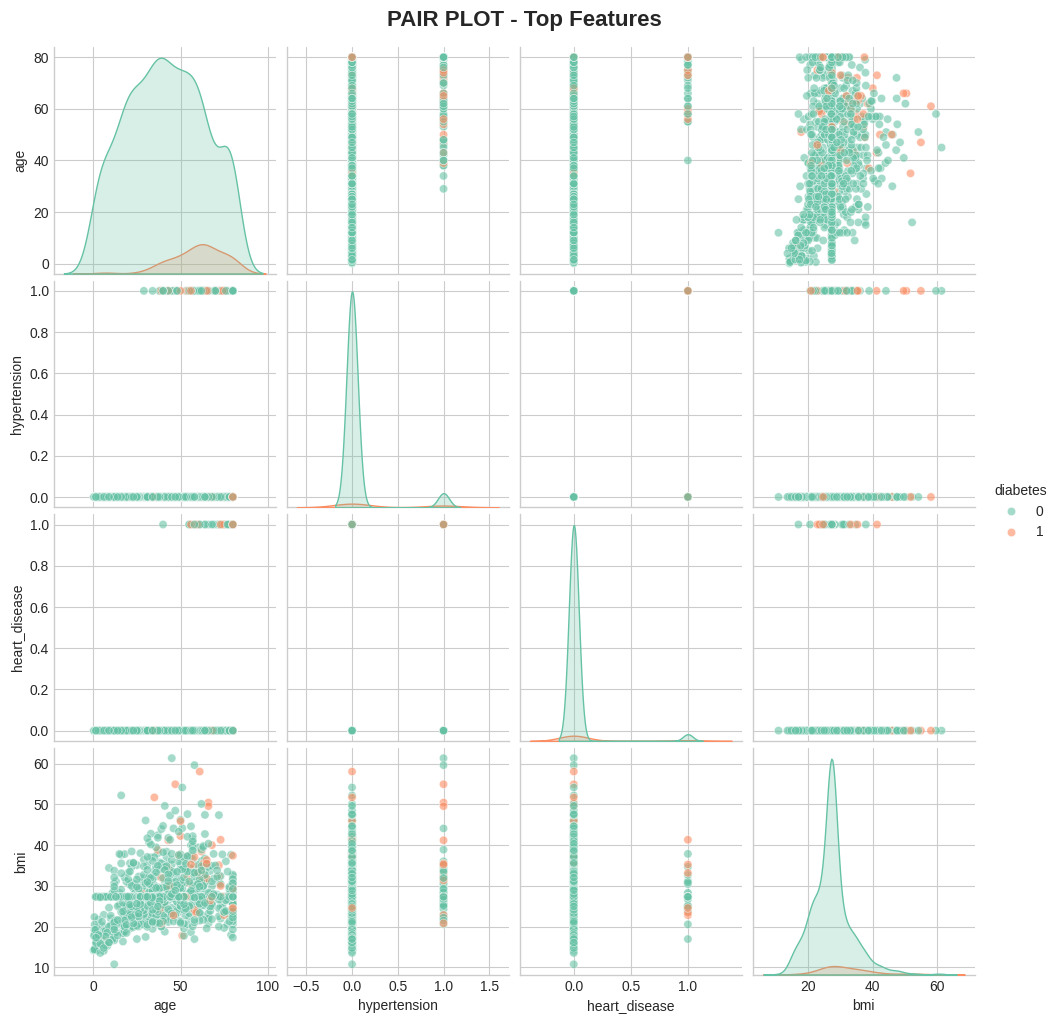

In [20]:
# Pair plot - En onemli 4 feature
if len(numeric_cols) >= 3:
    top_features = numeric_cols[:4] + [target_col]

    print('PAIR PLOT olusturuluyor...')
    pair_plot = sns.pairplot(df[top_features].sample(min(1000, len(df))),
                            hue=target_col, palette='Set2',
                            diag_kind='kde', plot_kws={'alpha': 0.6})
    pair_plot.fig.suptitle('PAIR PLOT - Top Features', y=1.02,
                          fontweight='bold', fontsize=16)
    plt.show()

## 4️⃣ VERI TEMIZLEME & FEATURE ENGINEERING

In [21]:
print('='*80)
print('VERI TEMIZLEME BASLADI')
print('='*80)

df_clean = df.copy()
original_size = len(df_clean)

# Duplicate kontrolu
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'{duplicates} duplicate kayit kaldirildi')

print(f'Temizlik sonrasi: {len(df_clean):,} kayit')
print('='*80)

VERI TEMIZLEME BASLADI
3854 duplicate kayit kaldirildi
Temizlik sonrasi: 96,146 kayit


In [22]:
# Feature Engineering
print('='*80)
print('FEATURE ENGINEERING')
print('='*80)

# BMI kategorileri (eger BMI varsa)
if 'bmi' in [c.lower() for c in df_clean.columns]:
    bmi_col = [c for c in df_clean.columns if c.lower() == 'bmi'][0]
    df_clean['bmi_category'] = pd.cut(df_clean[bmi_col],
                                      bins=[0, 18.5, 25, 30, 100],
                                      labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
    print('bmi_category olusturuldu')

# Age groups (eger age varsa)
if 'age' in [c.lower() for c in df_clean.columns]:
    age_col = [c for c in df_clean.columns if c.lower() == 'age'][0]
    df_clean['age_group'] = pd.cut(df_clean[age_col],
                                   bins=[0, 30, 45, 60, 100],
                                   labels=['Young', 'MiddleAge', 'Senior', 'Elderly'])
    print('age_group olusturuldu')

# Glucose kategorileri (eger glucose varsa)
glucose_cols = [c for c in df_clean.columns if 'glucose' in c.lower()]
if glucose_cols:
    df_clean['glucose_category'] = pd.cut(df_clean[glucose_cols[0]],
                                         bins=[0, 100, 126, 300],
                                         labels=['Normal', 'Prediabetes', 'Diabetes'])
    print('glucose_category olusturuldu')

# Blood pressure kategorileri
bp_cols = [c for c in df_clean.columns if 'blood_pressure' in c.lower()]
if bp_cols:
    df_clean['bp_category'] = pd.cut(df_clean[bp_cols[0]],
                                     bins=[0, 120, 140, 200],
                                     labels=['Normal', 'Elevated', 'High'])
    print('bp_category olusturuldu')

print(f'Guncel sutun sayisi: {len(df_clean.columns)}')
print('='*80)

FEATURE ENGINEERING
bmi_category olusturuldu
age_group olusturuldu
glucose_category olusturuldu
Guncel sutun sayisi: 12


In [23]:
# Eksik veri doldurma
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in df_clean.select_dtypes(include=['object', 'category']).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f'Eksik veri: {df_clean.isnull().sum().sum()}')

Eksik veri: 0


## 5️⃣ MODEL HAZIRLIGI

In [24]:
# Target ve features
y = df_clean[target_col].values
X = df_clean.drop(columns=[target_col]).copy()

# Encoding
for col in X.select_dtypes(include=['object', 'category']).columns:
    if X[col].nunique() <= 2:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    else:
        X = pd.get_dummies(X, columns=[col], drop_first=True)

print(f'Features: {X.shape[1]}')
print(f'Samples: {len(X):,}')

Features: 21
Samples: 96,146


In [25]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('='*80)
print('TRAIN-TEST SPLIT')
print('='*80)
print(f'Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)')
print('='*80)

TRAIN-TEST SPLIT
Train: 76,916 (80.0%)
Test: 19,230 (20.0%)


In [26]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('FEATURE SCALING TAMAMLANDI (StandardScaler)')

FEATURE SCALING TAMAMLANDI (StandardScaler)


In [27]:
# SMOTE
print('='*80)
print('SMOTE - CLASS IMBALANCE HANDLING')
print('='*80)

print('Onceki dagilim:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c:,} ({c/len(y_train)*100:.1f}%)')

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print('SMOTE sonrasi dagilim:')
unique, counts = np.unique(y_train_smote, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c:,} ({c/len(y_train_smote)*100:.1f}%)')

print('='*80)

SMOTE - CLASS IMBALANCE HANDLING
Onceki dagilim:
  Class 0: 70,130 (91.2%)
  Class 1: 6,786 (8.8%)
SMOTE sonrasi dagilim:
  Class 0: 70,130 (50.0%)
  Class 1: 70,130 (50.0%)


## 6️⃣ ML MODELLERI - EGITIM (10+ MODELS)

In [28]:
# Model tanimlama
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Ridge Classifier': RidgeClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=7, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=7, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, depth=7, random_state=42, verbose=False),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'LDA': LinearDiscriminantAnalysis()
}

print('='*80)
print(f'{len(models)} MODEL TANIMLANDI')
print('='*80)
for name in models.keys():
    print(f'  {name}')
print('='*80)

14 MODEL TANIMLANDI
  Logistic Regression
  Ridge Classifier
  Decision Tree
  Random Forest
  Gradient Boosting
  XGBoost
  LightGBM
  CatBoost
  SVM (RBF)
  KNN
  Naive Bayes
  AdaBoost
  Extra Trees
  LDA


In [29]:
# Model egitimi
results = {}

print('='*80)
print('MODEL EGITIMI BASLADI')
print('='*80)

for name, model in models.items():
    print(f'{name} egitiliyor...')

    # Egit
    model.fit(X_train_smote, y_train_smote)

    # Tahmin
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    # Metrikler
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Medical-specific metrics
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    if y_pred_proba is not None and len(np.unique(y_test)) == 2:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None

    # Kaydet
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'ROC_AUC': roc_auc,
        'predictions': y_pred,
        'pred_proba': y_pred_proba,
        'confusion_matrix': cm
    }

    print(f'   Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Sensitivity: {sensitivity:.4f}')

print('='*80)
print('TUM MODELLER EGITILDI!')
print('='*80)

MODEL EGITIMI BASLADI
Logistic Regression egitiliyor...
   Accuracy: 0.8810, F1: 0.8992, Sensitivity: 0.8962
Ridge Classifier egitiliyor...
   Accuracy: 0.8756, F1: 0.8952, Sensitivity: 0.9039
Decision Tree egitiliyor...
   Accuracy: 0.9129, F1: 0.9221, Sensitivity: 0.8261
Random Forest egitiliyor...
   Accuracy: 0.9252, F1: 0.9319, Sensitivity: 0.8331
Gradient Boosting egitiliyor...
   Accuracy: 0.9682, F1: 0.9665, Sensitivity: 0.7117
XGBoost egitiliyor...
   Accuracy: 0.9679, F1: 0.9662, Sensitivity: 0.7146
LightGBM egitiliyor...
   Accuracy: 0.9694, F1: 0.9675, Sensitivity: 0.7111
CatBoost egitiliyor...
   Accuracy: 0.9691, F1: 0.9673, Sensitivity: 0.7146
SVM (RBF) egitiliyor...
   Accuracy: 0.8783, F1: 0.8972, Sensitivity: 0.9027
KNN egitiliyor...
   Accuracy: 0.9012, F1: 0.9124, Sensitivity: 0.7930
Naive Bayes egitiliyor...
   Accuracy: 0.3779, F1: 0.4596, Sensitivity: 0.9929
AdaBoost egitiliyor...
   Accuracy: 0.9189, F1: 0.9272, Sensitivity: 0.8467
Extra Trees egitiliyor...
   A

## 7️⃣ KAPSAMLI MODEL KARSILASTIRMASI

### 📊 Tablo Karsilastirmasi

In [30]:
# Sonuc tablosu
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['Accuracy'] for m in results.keys()],
    'Precision': [results[m]['Precision'] for m in results.keys()],
    'Recall': [results[m]['Recall'] for m in results.keys()],
    'F1 Score': [results[m]['F1_Score'] for m in results.keys()],
    'Sensitivity': [results[m]['Sensitivity'] for m in results.keys()],
    'Specificity': [results[m]['Specificity'] for m in results.keys()],
    'ROC-AUC': [results[m]['ROC_AUC'] if results[m]['ROC_AUC'] else 0 for m in results.keys()]
})

results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)

print('='*120)
print('MODEL PERFORMANS KARSILASTIRMASI - TABLO')
print('='*120)
print(results_df.to_string(index=False))
print('='*120)

best_model_name = results_df.iloc[0]['Model']
print(f'EN IYI MODEL: {best_model_name}')
print(f'   F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
print(f'   Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')
print(f'   Sensitivity: {results_df.iloc[0]["Sensitivity"]:.4f}')
print('='*120)

MODEL PERFORMANS KARSILASTIRMASI - TABLO
              Model  Accuracy  Precision  Recall  F1 Score  Sensitivity  Specificity  ROC-AUC
           LightGBM    0.9694     0.9684  0.9694    0.9675       0.7111       0.9944   0.9749
           CatBoost    0.9691     0.9680  0.9691    0.9673       0.7146       0.9937   0.9733
  Gradient Boosting    0.9682     0.9670  0.9682    0.9665       0.7117       0.9930   0.9748
            XGBoost    0.9679     0.9665  0.9679    0.9662       0.7146       0.9924   0.9745
      Random Forest    0.9252     0.9448  0.9252    0.9319       0.8331       0.9341   0.9709
           AdaBoost    0.9189     0.9437  0.9189    0.9272       0.8467       0.9259   0.9702
      Decision Tree    0.9129     0.9399  0.9129    0.9221       0.8261       0.9214   0.9651
                KNN    0.9012     0.9332  0.9012    0.9124       0.7930       0.9117   0.9028
        Extra Trees    0.8841     0.9394  0.8841    0.9015       0.8998       0.8826   0.9640
Logistic Regression

### 📊 Gorsel Karsilastirma - Part 1 (Basic Metrics)

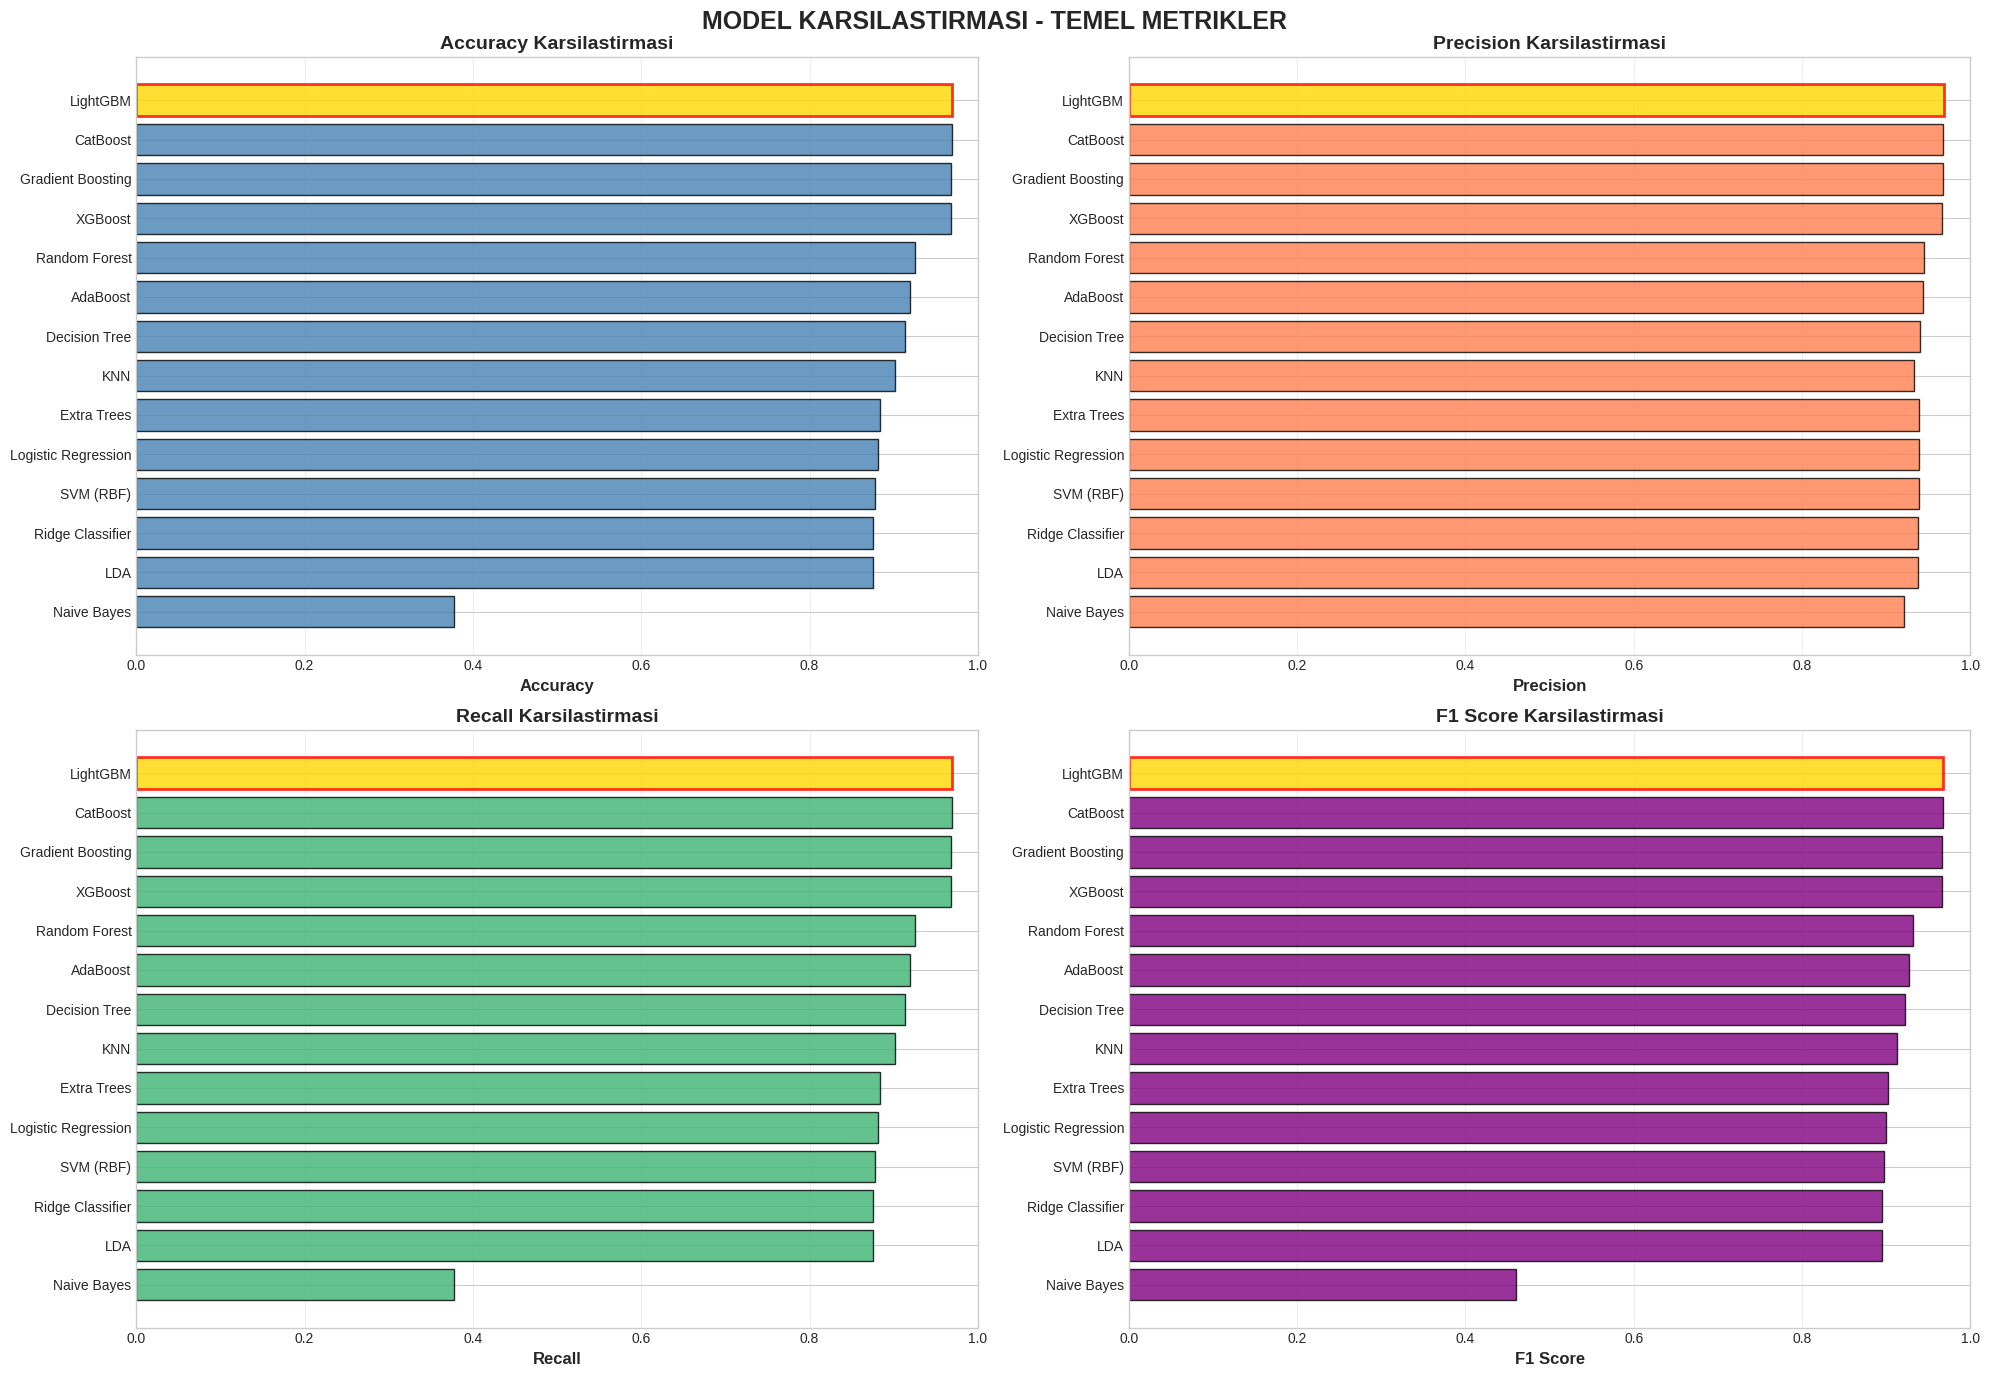

In [31]:
# 4 temel metrik karsilastirmasi
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('MODEL KARSILASTIRMASI - TEMEL METRIKLER', fontsize=18, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['steelblue', 'coral', 'mediumseagreen', 'purple']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx // 2, idx % 2]
    ax.barh(results_df['Model'], results_df[metric],
           color=color, edgecolor='black', alpha=0.8)
    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Karsilastirmasi', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

    # En iyi modeli vurgula
    max_idx = results_df[metric].idxmax()
    ax.get_children()[max_idx].set_color('gold')
    ax.get_children()[max_idx].set_edgecolor('red')
    ax.get_children()[max_idx].set_linewidth(2)

plt.tight_layout()
plt.show()

### 📊 Gorsel Karsilastirma - Part 2 (Medical Metrics)

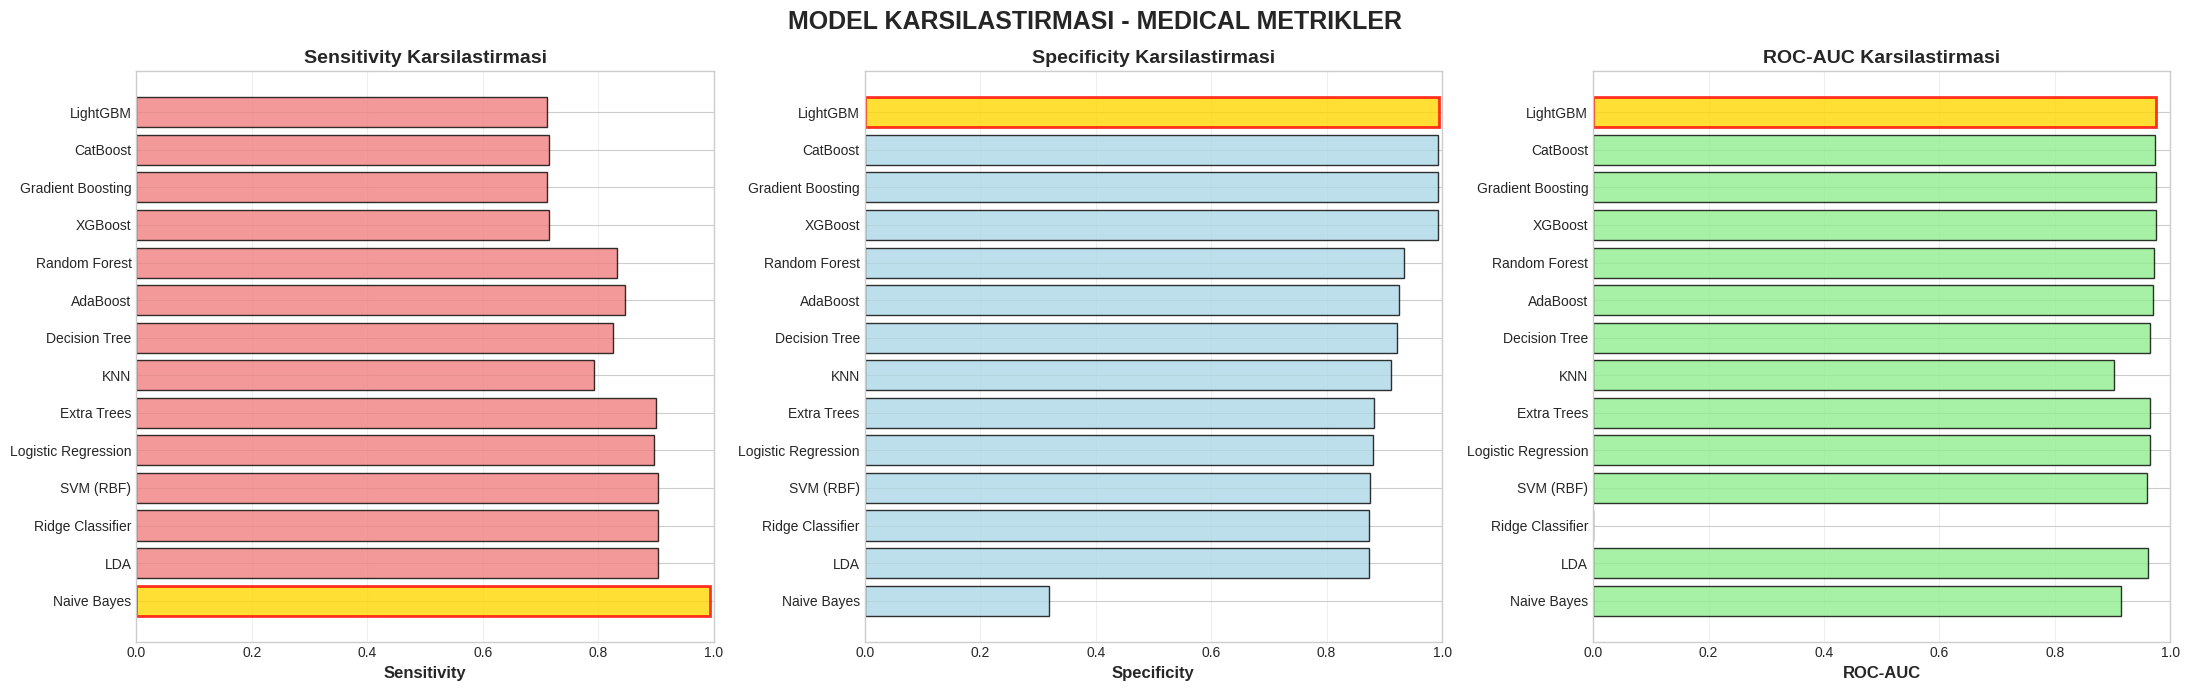

In [32]:
# Medical-specific metrics
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('MODEL KARSILASTIRMASI - MEDICAL METRIKLER', fontsize=18, fontweight='bold')

medical_metrics = ['Sensitivity', 'Specificity', 'ROC-AUC']
colors = ['lightcoral', 'lightblue', 'lightgreen']

for idx, (metric, color) in enumerate(zip(medical_metrics, colors)):
    axes[idx].barh(results_df['Model'], results_df[metric],
                  color=color, edgecolor='black', alpha=0.8)
    axes[idx].set_xlabel(metric, fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{metric} Karsilastirmasi', fontsize=14, fontweight='bold')
    axes[idx].set_xlim(0, 1)
    axes[idx].grid(axis='x', alpha=0.3)
    axes[idx].invert_yaxis()

    # En iyi modeli vurgula
    max_idx = results_df[metric].idxmax()
    axes[idx].get_children()[max_idx].set_color('gold')
    axes[idx].get_children()[max_idx].set_edgecolor('red')
    axes[idx].get_children()[max_idx].set_linewidth(2)

plt.tight_layout()
plt.show()

### 📊 Gorsel Karsilastirma - Part 3 (Radar Chart)

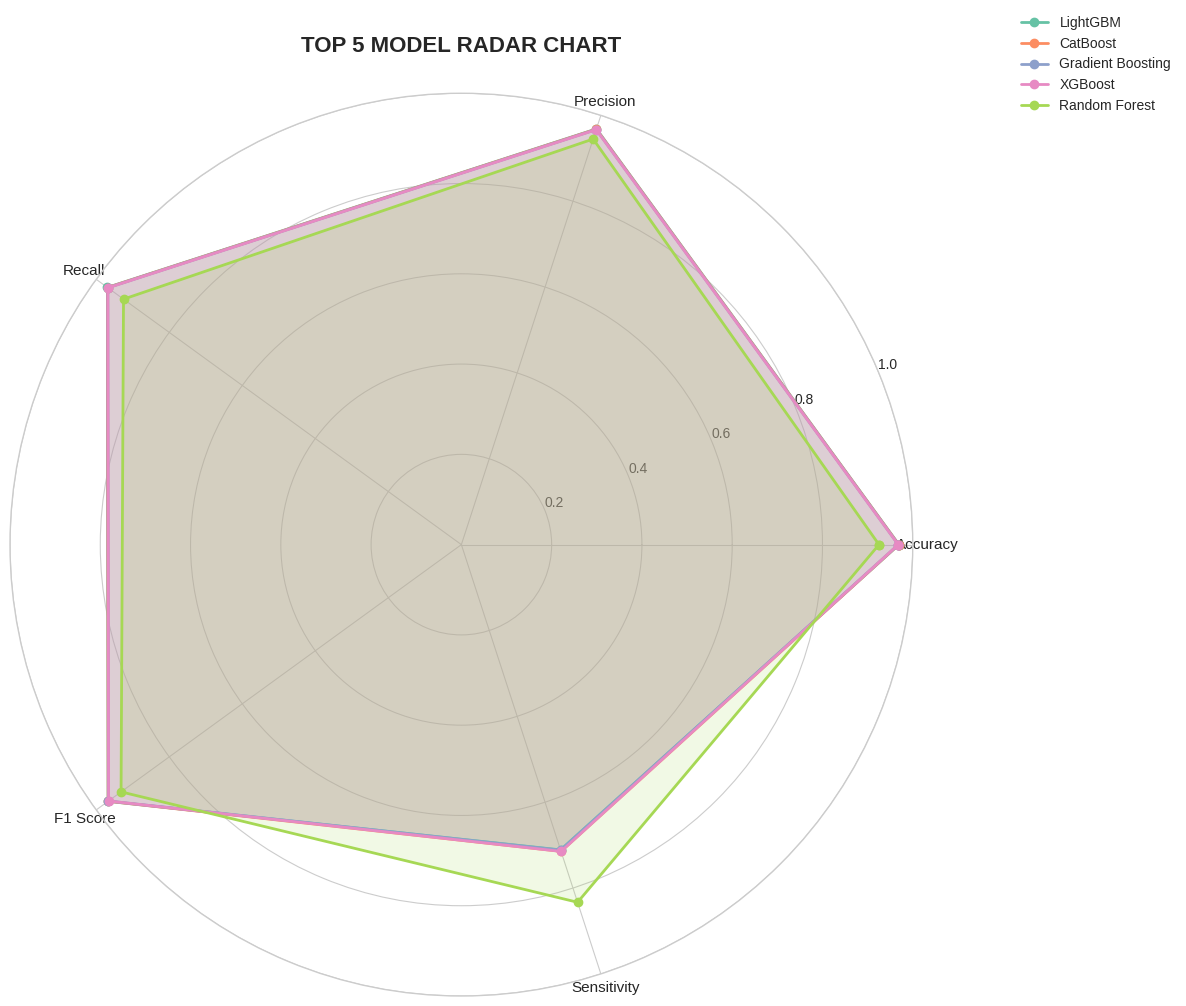

In [33]:
# Top 5 model radar chart
top_5 = results_df.head(5)['Model'].tolist()
metrics_for_radar = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Sensitivity']

angles = np.linspace(0, 2 * np.pi, len(metrics_for_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))

for model_name in top_5:
    model_data = results_df[results_df['Model'] == model_name].iloc[0]
    values = [model_data[m] for m in metrics_for_radar]
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=2, label=model_name)
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_for_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('TOP 5 MODEL RADAR CHART', fontweight='bold', fontsize=16, pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()

### 📊 Gorsel Karsilastirma - Part 4 (Confusion Matrices)

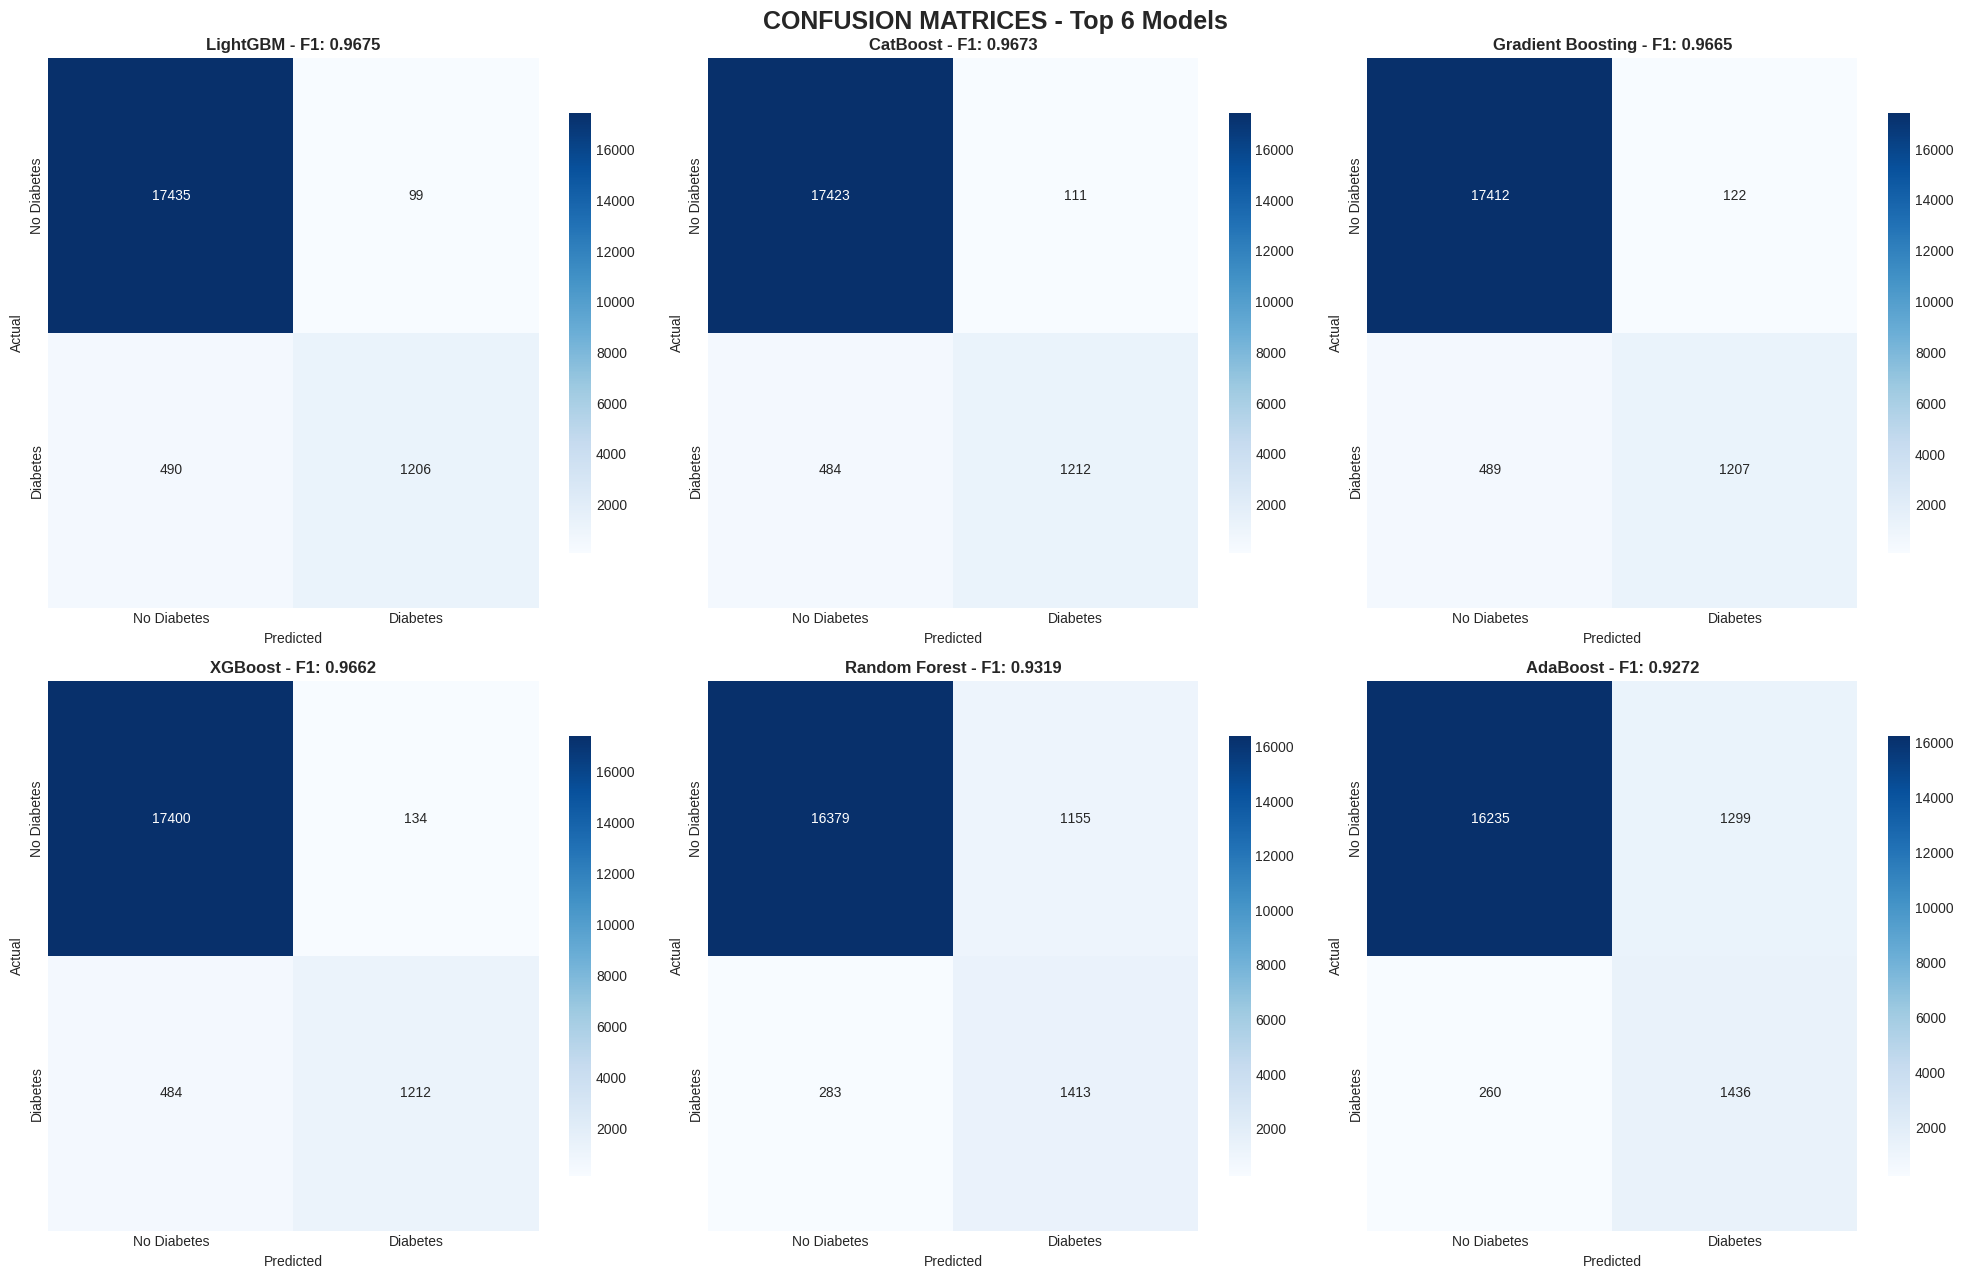

In [34]:
# Top 6 model confusion matrices
top_6 = results_df.head(6)['Model'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
fig.suptitle('CONFUSION MATRICES - Top 6 Models', fontsize=18, fontweight='bold')

for idx, model_name in enumerate(top_6):
    ax = axes[idx // 3, idx % 3]
    cm = results[model_name]['confusion_matrix']

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
               xticklabels=['No Diabetes', 'Diabetes'],
               yticklabels=['No Diabetes', 'Diabetes'],
               cbar_kws={'shrink': 0.8})

    ax.set_title(f'{model_name} - F1: {results[model_name]["F1_Score"]:.4f}',
                fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 📊 Gorsel Karsilastirma - Part 5 (ROC Curves)

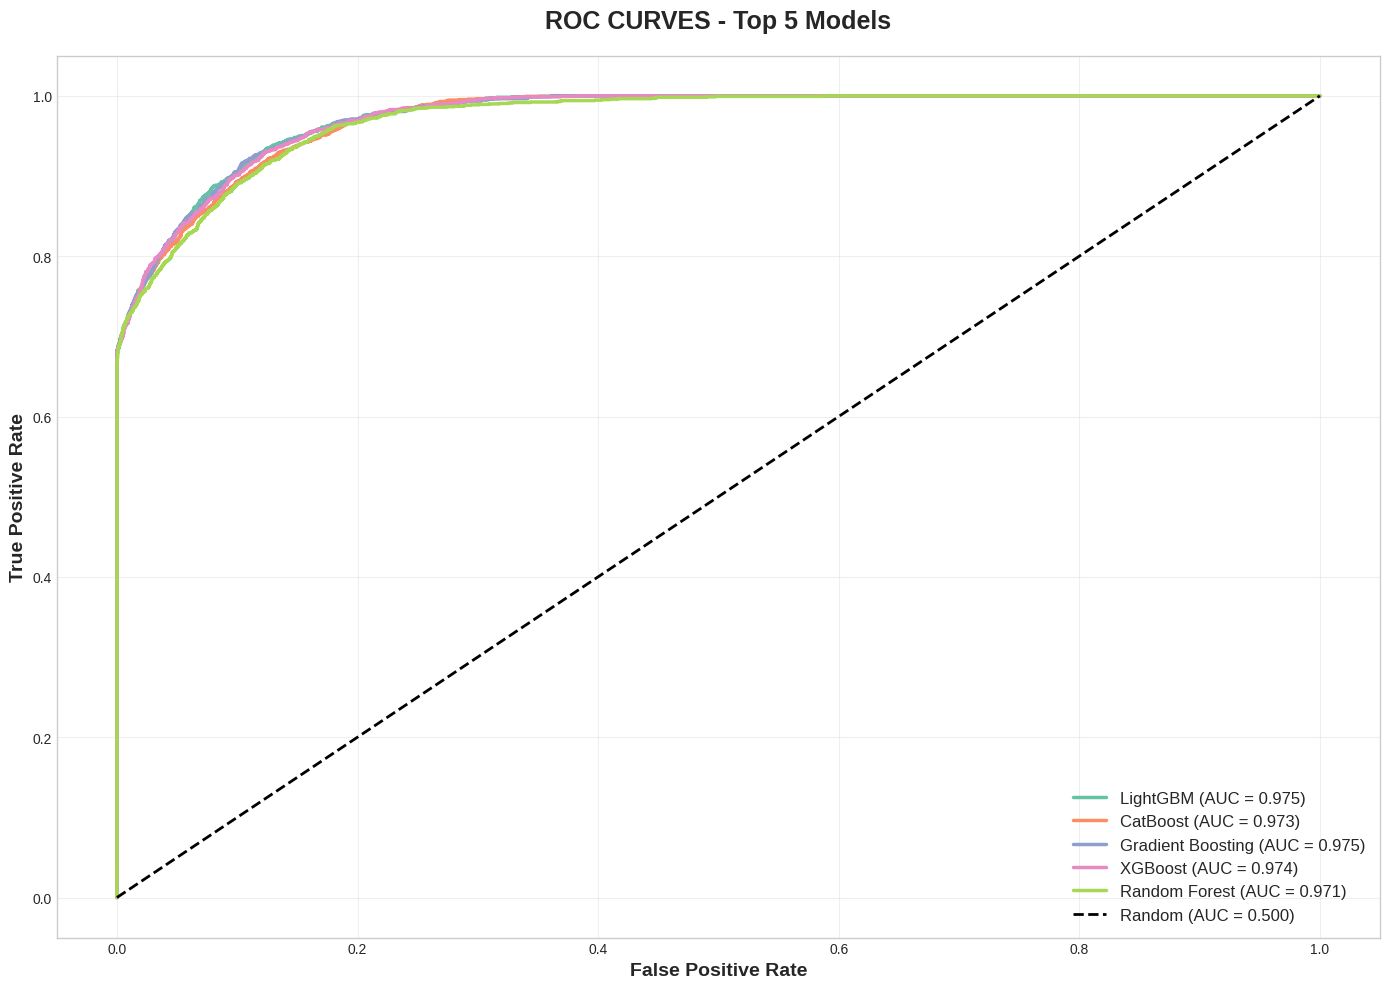

In [35]:
# ROC Curves
plt.figure(figsize=(14, 10))

for model_name in top_5:
    if results[model_name]['pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results[model_name]['pred_proba'])
        roc_auc = results[model_name]['ROC_AUC']
        plt.plot(fpr, tpr, linewidth=2.5,
                label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('ROC CURVES - Top 5 Models', fontsize=18, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Gorsel Karsilastirma - Part 6 (Precision-Recall Curves)

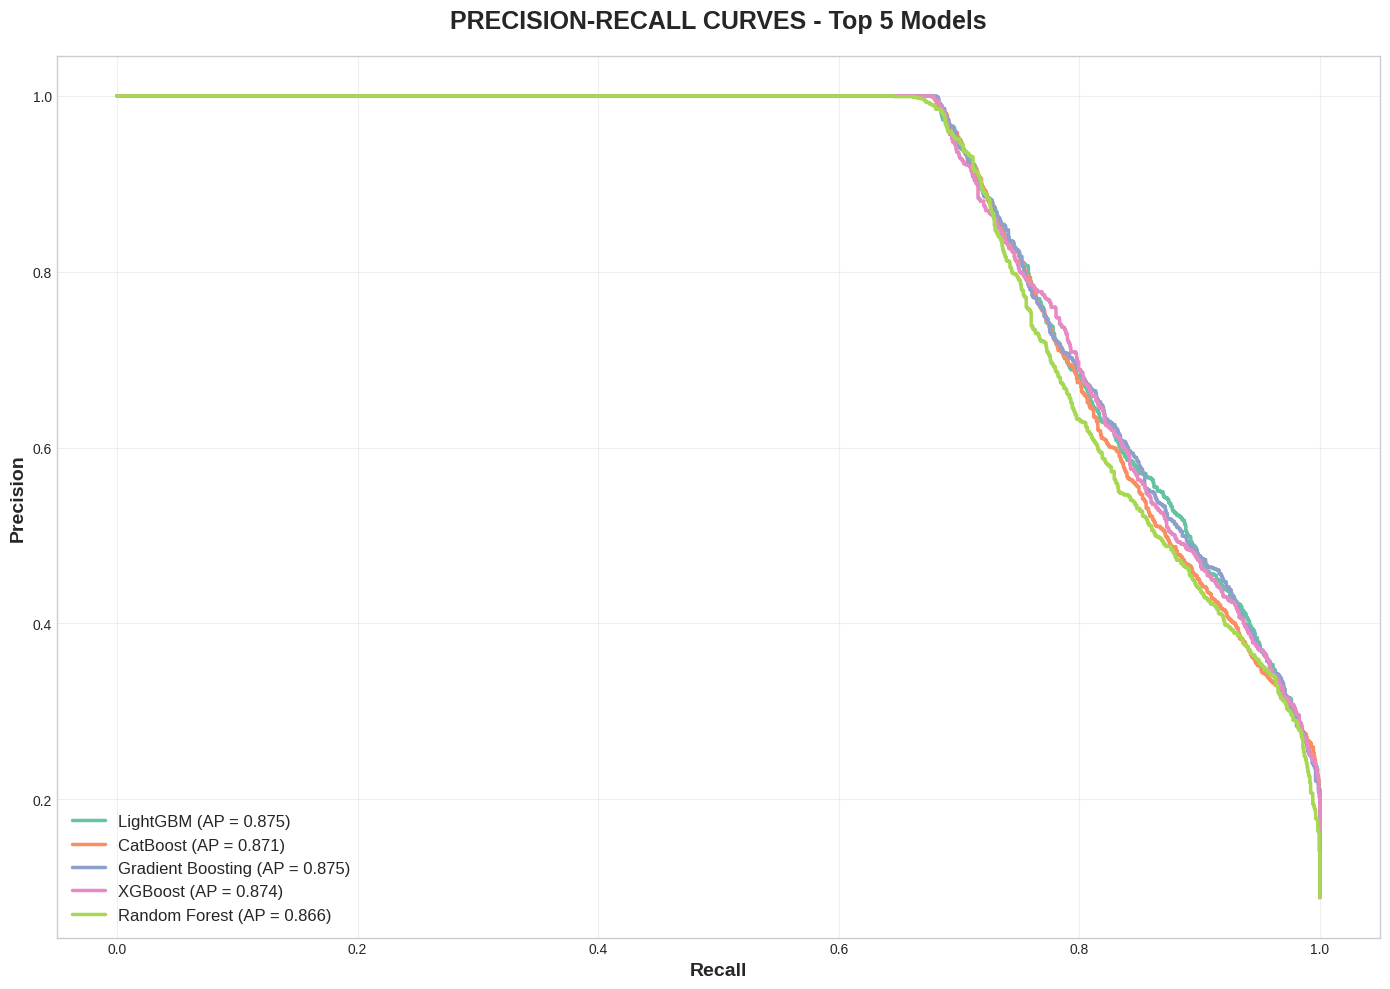

In [36]:
# Precision-Recall Curves
plt.figure(figsize=(14, 10))

for model_name in top_5:
    if results[model_name]['pred_proba'] is not None:
        precision, recall, _ = precision_recall_curve(y_test, results[model_name]['pred_proba'])
        avg_precision = average_precision_score(y_test, results[model_name]['pred_proba'])
        plt.plot(recall, precision, linewidth=2.5,
                label=f'{model_name} (AP = {avg_precision:.3f})')

plt.xlabel('Recall', fontsize=14, fontweight='bold')
plt.ylabel('Precision', fontsize=14, fontweight='bold')
plt.title('PRECISION-RECALL CURVES - Top 5 Models', fontsize=18, fontweight='bold', pad=20)
plt.legend(loc='lower left', fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Gorsel Karsilastirma - Part 7 (Metric Heatmap)

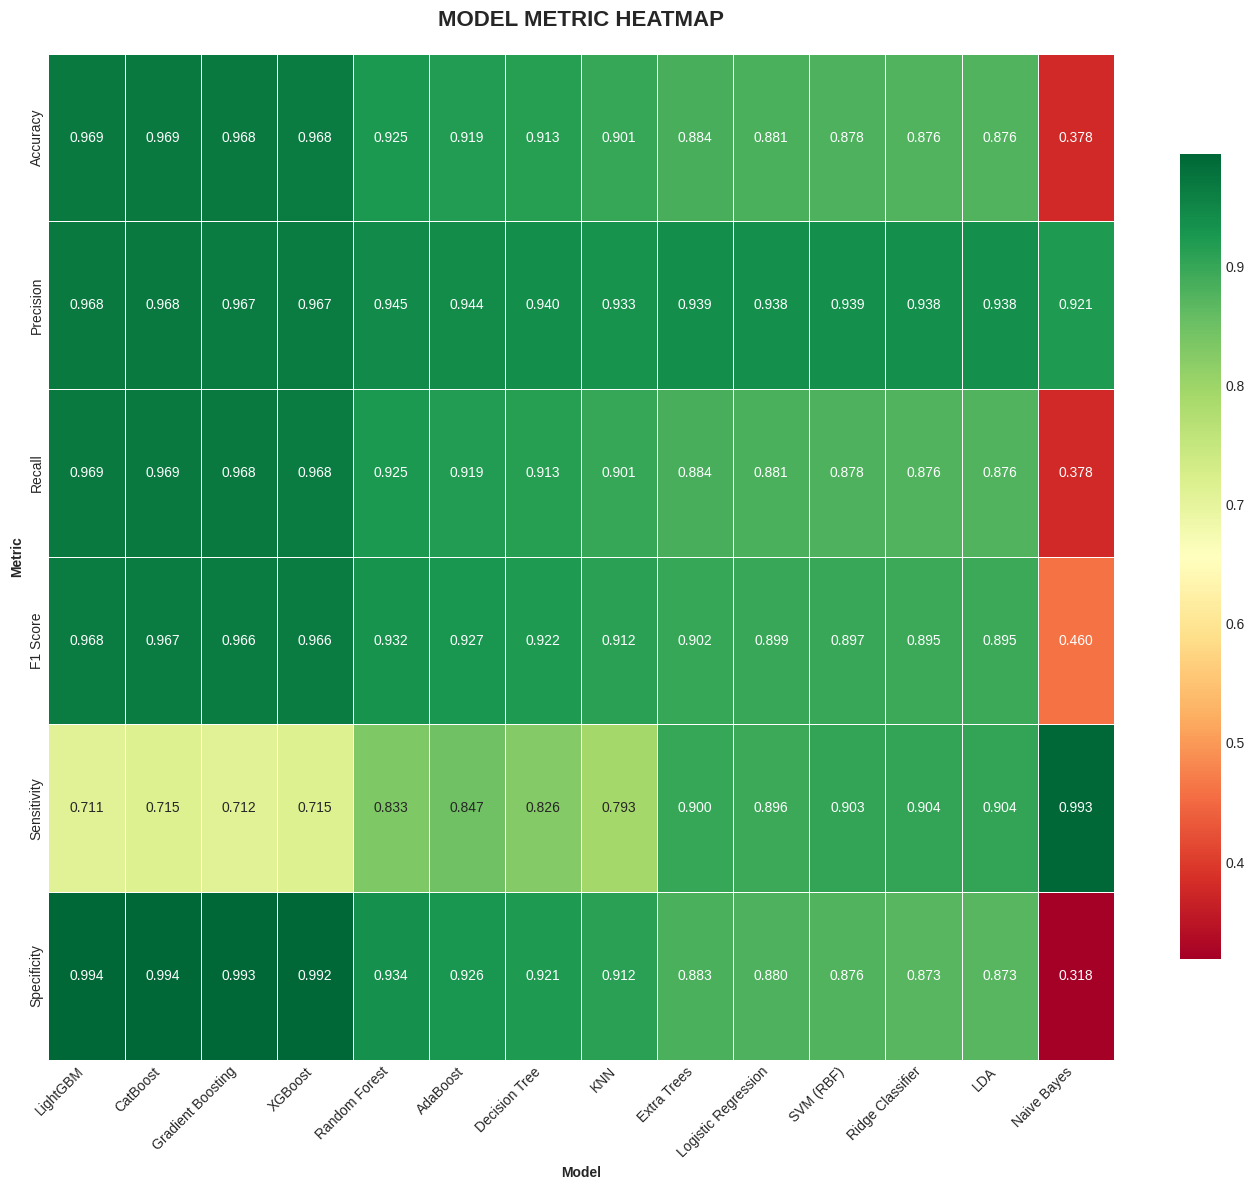

In [37]:
# Model metrik heatmap
heatmap_metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Sensitivity', 'Specificity']
heatmap_data = results_df[['Model'] + heatmap_metrics].set_index('Model')

plt.figure(figsize=(14, 12))
sns.heatmap(heatmap_data.T, annot=True, fmt='.3f', cmap='RdYlGn',
           linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('MODEL METRIC HEATMAP', fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Model', fontweight='bold')
plt.ylabel('Metric', fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 8️⃣ FINAL SONUCLAR & MEDICAL INSIGHTS

In [38]:
print('='*100)
print('FINAL SONUCLAR - DIABETES PREDICTION')
print('='*100)

print('1. DATASET BILGILERI:')
print(f'   Toplam Kayit: {len(df):,}')
print(f'   Final Features: {X.shape[1]}')
print(f'   Train Set: {len(X_train):,} (SMOTE: {len(X_train_smote):,})')
print(f'   Test Set: {len(X_test):,}')

print('2. EN IYI MODEL:')
print(f'   Model: {best_model_name}')
print(f'   Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')
print(f'   F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
print(f'   Sensitivity: {results_df.iloc[0]["Sensitivity"]:.4f}')
print(f'   Specificity: {results_df.iloc[0]["Specificity"]:.4f}')
print(f'   ROC-AUC: {results_df.iloc[0]["ROC-AUC"]:.4f}')

print('3. TOP 5 MODELS:')
for idx, row in results_df.head(5).iterrows():
    print(f'   {idx+1}. {row["Model"]:25} - F1: {row["F1 Score"]:.4f}, Sens: {row["Sensitivity"]:.4f}')

print('4. MEDICAL INSIGHTS:')
print('   - Sensitivity (True Positive Rate): Hasta olanlari dogru tespit etme')
print('   - Specificity (True Negative Rate): Saglikli olanlari dogru tespit etme')
print('   - Diyabet tespitinde False Negative (FN) cok kritik!')
print('   - Yuksek Sensitivity = Hasta tespit orani yuksek')
print(f'   - En iyi model: {best_model_name}')

print('5. GORSELLESTIRME OZETI:')
print('   - 20+ Farkli Grafik')
print('   - 7 Part Model Karsilastirmasi')
print('   - Confusion Matrices (Top 6)')
print('   - ROC Curves')
print('   - Precision-Recall Curves')
print('   - Radar Chart')
print('   - Metric Heatmap')

print('6. ONERILER:')
print(f'   - Model: {best_model_name} kullanilmali')
print('   - Threshold ayarlamasi yapilabilir (ROC curve bazli)')
print('   - Daha fazla feature engineering denenebilir')
print('   - Hyperparameter tuning ile performans artabilir')

print('='*100)
print('DIABETES PREDICTION PROJESI TAMAMLANDI!')
print('='*100)

FINAL SONUCLAR - DIABETES PREDICTION
1. DATASET BILGILERI:
   Toplam Kayit: 100,000
   Final Features: 21
   Train Set: 76,916 (SMOTE: 140,260)
   Test Set: 19,230
2. EN IYI MODEL:
   Model: LightGBM
   Accuracy: 0.9694
   F1 Score: 0.9675
   Sensitivity: 0.7111
   Specificity: 0.9944
   ROC-AUC: 0.9749
3. TOP 5 MODELS:
   1. LightGBM                  - F1: 0.9675, Sens: 0.7111
   2. CatBoost                  - F1: 0.9673, Sens: 0.7146
   3. Gradient Boosting         - F1: 0.9665, Sens: 0.7117
   4. XGBoost                   - F1: 0.9662, Sens: 0.7146
   5. Random Forest             - F1: 0.9319, Sens: 0.8331
4. MEDICAL INSIGHTS:
   - Sensitivity (True Positive Rate): Hasta olanlari dogru tespit etme
   - Specificity (True Negative Rate): Saglikli olanlari dogru tespit etme
   - Diyabet tespitinde False Negative (FN) cok kritik!
   - Yuksek Sensitivity = Hasta tespit orani yuksek
   - En iyi model: LightGBM
5. GORSELLESTIRME OZETI:
   - 20+ Farkli Grafik
   - 7 Part Model Karsilastirma